In [37]:
import numpy as np
from astropy.io import fits
from pathlib import Path
from scipy.optimize import curve_fit
from scipy.signal import convolve2d
import matplotlib.pyplot as plt

In [38]:
fits_path = Path(f'../matched_filter/mf_data/mf_catalogs/26p5_2000/storm_2')
gal = "storm_2"

D = 2000
size_kpc = 40
pdist = (size_kpc/D) * (180/np.pi)
pix = 8000

# provide a sensible initial guess (p0) to prevent divergence
# form: [A, h, q, x_offset, y_offset, theta, C]
initial_guess = [440, 3, 1, 7.7, -0.2, 0, -0.2]
mask_cutoff = 0.05

In [39]:
# 2d fitting function, pass to the func below - copy past from dimitra + nolan 
def twoD_exponential(coords, A, h, q, x_offset, y_offset, theta, C):
    """ The 2D exponential model function.

    Params:
        coords (2D array of floats):
            The 2D array of data in the XY plane.
        A (float):
            Amplitude.
        h (float):
            Scale length.
        q (float):
            Axis ratio (minor/major; related to orientation).
        x_offset (float):
            distance of the center of the galaxy from the center of the image on the x-axis.
        y_offset (float):
            distance of the center of the galaxy from the center of the image on the y-axis.
        theta (float):
            Rotation angle in viewing plane (0 means major axis is along the x-axis, pi/2 means major axis is along the y-axis).
        C (float):
            Offset from background (should be about 0).

    Returns:
        exp_fit (array of floats):
            The calculated 2D exponential fit values.
    """
    x = coords[0] - x_offset
    y = coords[1] - y_offset
    x_prime = x * np.cos(theta) + y * np.sin(theta)
    y_prime = -x * np.sin(theta) + y * np.cos(theta)
    r = np.sqrt(x_prime**2 + y_prime**2/q**2)
    exp_fit = A * np.exp(-r/h) + C
    return exp_fit

In [48]:
# reads in mf map npz, fits exponential profile to main galaxy, subtracts + plots the leftovers  
def mf_exp_fit_edge_detect(fits_path, pdist, pix, initial_guess, mask_cutoff = 0.05, save=False):
    print("Fitting 2D Exponential to MF Map ... ")
    
    # open .fits files
    for file in sorted(fits_path.iterdir()):
        if file.is_file():
            # print the structure to see where the data lives
            hdul = fits.open(f'{fits_path}/{file.name}')
            hdul.info()
            data = hdul[0].data
            
            # extract the target data arrays
            image_data = hdul[0].data
            
            # save the extracted arrays into a compressed .npz file
            npz_path = Path(f'mf_npz_catalogs/{gal}')
            npz_path.mkdir(parents=True, exist_ok=True)
            np.savez_compressed(f"{npz_path}/{file.stem}.npz", sig_array=image_data)

            npz = f'{npz_path}/{file.stem}.npz'
            sig_array = np.load(npz)['sig_array']
            levels = [4,5,7,10,20,50,100,150]
        
            # generate grid of the same size as the mf map to fit over 
            x_line = np.linspace(-60, 60, 89)
            y_line = np.linspace(-60, 60, 89)
            X, Y = np.meshgrid(x_line, y_line)
            
            # Flatten the arrays to 1-D for curve_fit
            x_flat = X.ravel()
            y_flat = Y.ravel()
            z_flat = sig_array.ravel()
            independent_vars = np.vstack((x_flat, y_flat))
        
            # do the fit 
            try:
                fitted_params, covariance = curve_fit(
                        f=twoD_exponential, 
                        xdata=independent_vars, 
                        ydata=z_flat, 
                        p0=initial_guess
                    )
            except RuntimeError:
                    print('No Fit Convergence')
                    return
        
            Z_fitted = twoD_exponential((X, Y), *fitted_params)
        
            # postprocessing - finding the max, subtract model, mask leftover central bins - this might need to go in favor of setting bins w/i X% of max to zero, no fitting at all?
            z_fit_max = np.max(Z_fitted)
            print("z_fit_max:",mask_cutoff * z_fit_max)
            mask_thresh = mask_cutoff * z_fit_max # set a cutoff here - for inner pixels that are not well modeleld by the exponential, set to 0
            mask = Z_fitted < mask_thresh
            residual = sig_array - Z_fitted # subtracts the fit from the whole mf map, fit was on higher confience region
            masked_residual = residual.copy()
            masked_residual[~mask] = 0 # after subtracting, set values that are above some cutoff to zero
        
            # hilighting pixels after model subtraction that are still above the 4 sigma level AND have at least N neightbors that are not None
            significant_mask = masked_residual >= 4. # masking the residual w/ some cutoff significance, here is 4 sigma
            significant_masked_residual = masked_residual.copy()
            significant_masked_residual[~significant_mask] = None
            kernel = np.ones((3,3)) # n-neighbors kernel from stack overflow 
            kernel[1,1] = 0
            n_neighbors = convolve2d(significant_mask, kernel, mode='same', boundary='fill') # do convolution
            neighbor_mask = n_neighbors < 4 # chuck significant pixels with less than N neighbors that are also significant - here N is 4
            neighbor_residual = masked_residual.copy()
            neighbor_residual[neighbor_mask] = None # set to none for visualizaing 
        
            # now using an edge detection kernel to get the boundary
            fil = np.ones((3,3)) * -1
            fil[1,1] = 8
            convolution = convolve2d(neighbor_mask,fil, mode='same', boundary='fill',fillvalue=None)
            yedges,xedges = np.where(convolution > 1) # in pixel coordinates, values above 1 represent an edge w/ this kernel
        
            xedges_arcmin = None # used in conditional later for plotting 
            if (convolution > 1).any() == True: # conditional for the case of no blobs with edges to detect, if False then skip 
                xedges_arcmin = (xedges - int(pdist/pix) - 0.5) * (pix)
                np.append(xedges_arcmin,xedges_arcmin[-1]) # matplotlib Path objects need the first and last point to be the same so the loop closes
                yedges_arcmin = (yedges - int(pdist/pix) - 0.5) * (pix)
                np.append(yedges_arcmin,yedges_arcmin[-1])
        
                #### this can be returned / writtin out to use for future analysis ####
                edges_arcmin = np.array([xedges_arcmin,yedges_arcmin]).T 
        
            #### clipping the sig_array above and below some value, not a good solution and this shows why 
            sig_clip_mask = ((sig_array >= 4.) & (sig_array < 20.)) # mask for whole 2D array 
            sigarr_clip = sig_array.copy()
            sigarr_clip[~sig_clip_mask] = None
        
            # plotting all three 
            fig,axs = plt.subplots(nrows=1,ncols=3)
            fig.set_figheight(7)
            fig.set_figwidth(23)
        
            axs[0].imshow(sig_array[::-1,:],extent=[-pdist,pdist,-pdist,pdist], \
                    cmap = 'gray_r', vmin = -15, vmax = 30)
            axs[0].imshow(sigarr_clip[::-1,:],extent=[-pdist,pdist,-pdist,pdist], \
                    cmap = 'Blues', vmin = -15, vmax = 30)
            axs[0].contour(x_line, y_line, sig_array, levels=levels)
        
            axs[1].imshow(Z_fitted[::-1,:],extent=[-pdist,pdist,-pdist,pdist], \
                    cmap = 'gray_r', vmin = -15, vmax = 30)
            
            axs[2].imshow(masked_residual[::-1,:],extent=[-pdist,pdist,-pdist,pdist], \
                    cmap = 'gray_r', vmin = -15, vmax = 30)
            axs[2].imshow(significant_masked_residual[::-1,:],extent=[-pdist,pdist,-pdist,pdist], \
                        cmap = 'Reds', vmin = -15, vmax = 30)
            axs[2].imshow(neighbor_residual[::-1,:],extent=[-pdist,pdist,-pdist,pdist], \
                            cmap = 'Blues', vmin = -15, vmax = 30)
            # axs[2].add_patch(PathPatch(edges_path,facecolor='none',edgecolor='k'))
            # if xedges_arcmin is not None: 
            #     axs[2].scatter(xedges_arcmin,yedges_arcmin,s=1,c='k')
            
            # axs[2].contour(x_line, y_line, masked_residual, levels=levels)
        
            plt.tight_layout()
            
            plt.show()
        
    return

Fitting 2D Exponential to MF Map ... 
Filename: ../matched_filter/mf_data/mf_catalogs/26p5_2000/storm_2/mf_storm_2_d=0.0_a=0.0_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (89, 89)   float64   
z_fit_max: 17.896003275681846


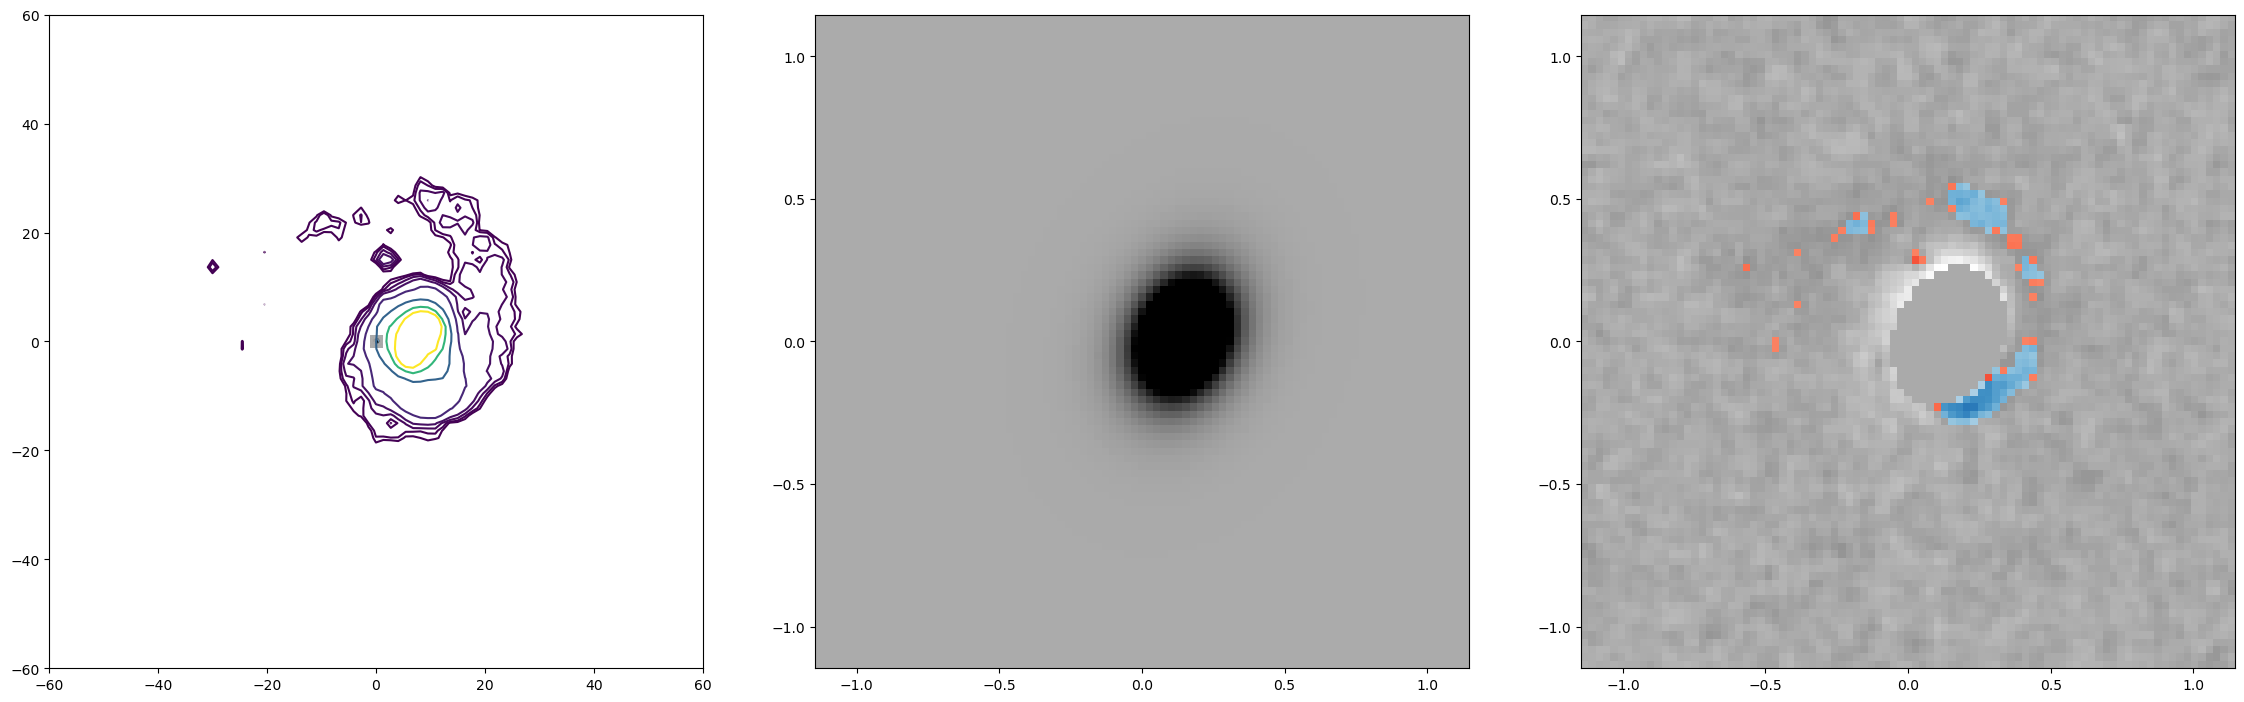

Filename: ../matched_filter/mf_data/mf_catalogs/26p5_2000/storm_2/mf_storm_2_d=17.0_a=222.5_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (89, 89)   float64   
z_fit_max: 17.74449156944482


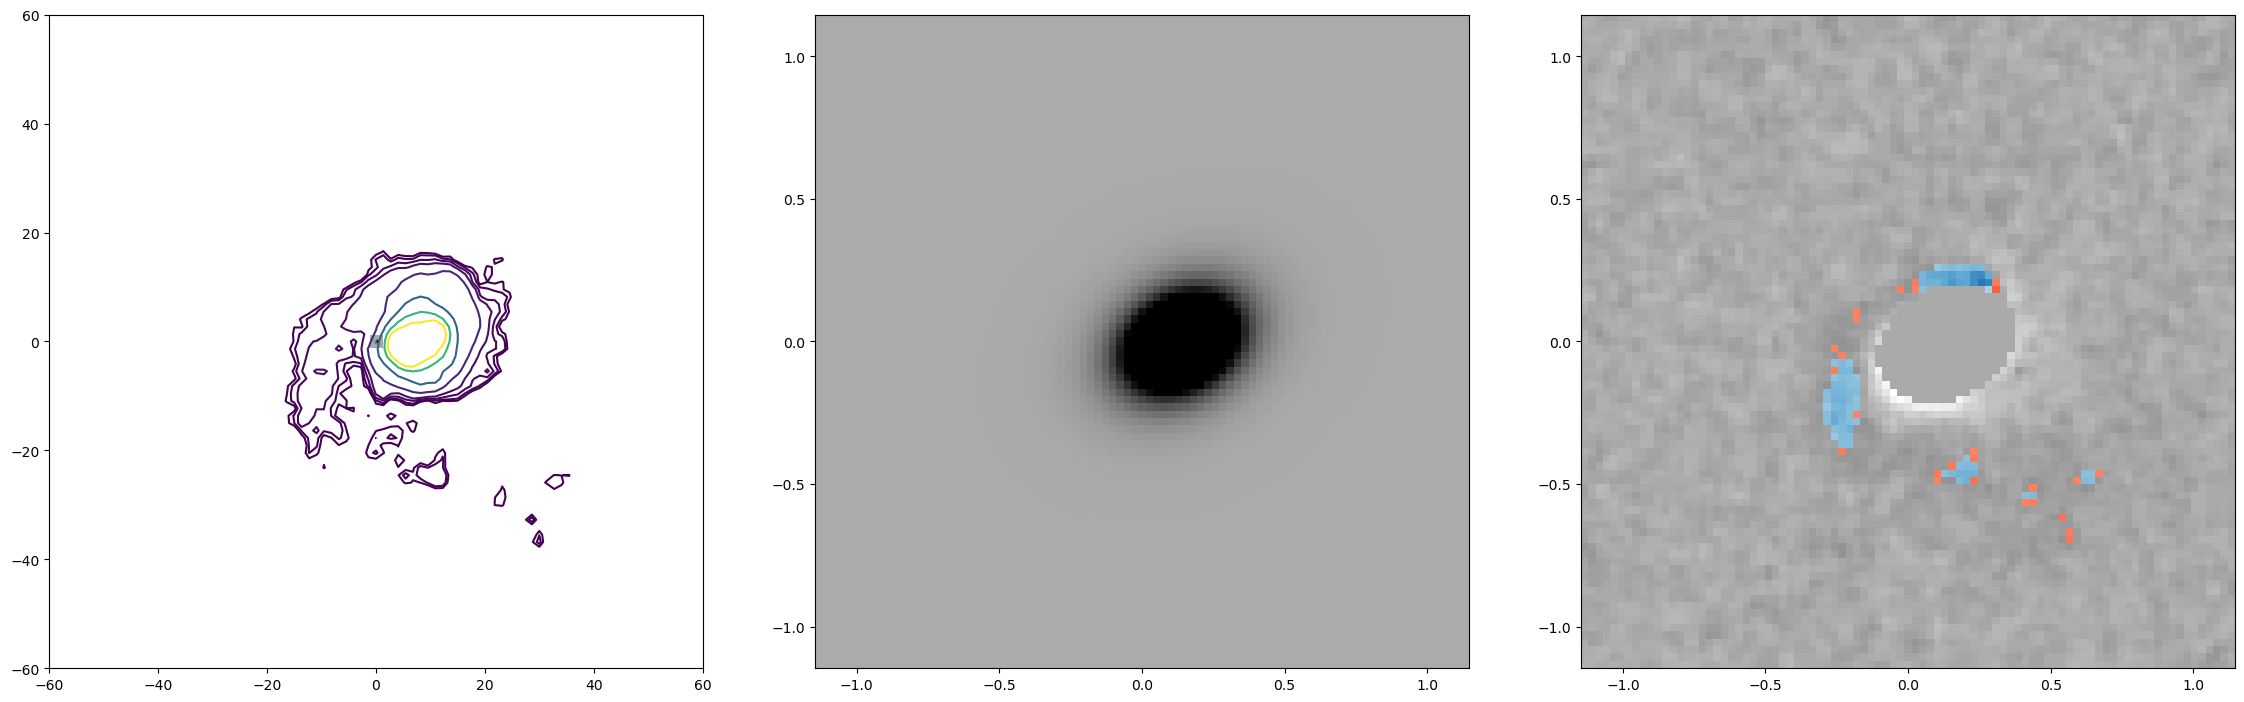

Filename: ../matched_filter/mf_data/mf_catalogs/26p5_2000/storm_2/mf_storm_2_d=24.1_a=85.0_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (89, 89)   float64   
z_fit_max: 22.23409873999972


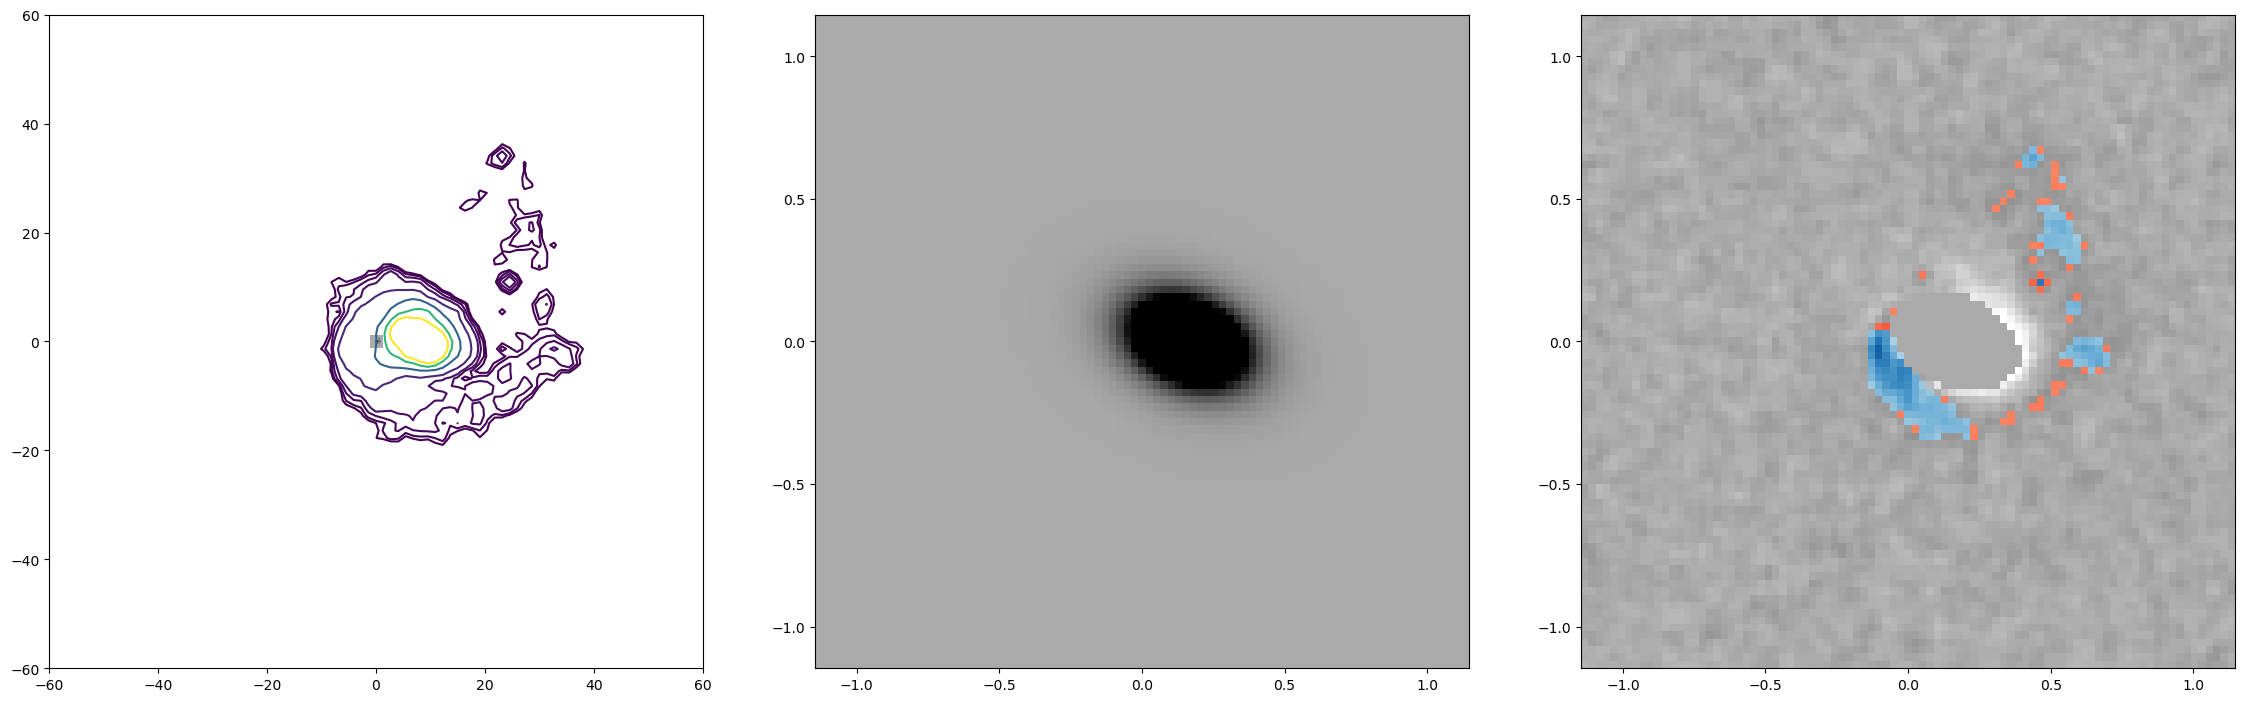

Filename: ../matched_filter/mf_data/mf_catalogs/26p5_2000/storm_2/mf_storm_2_d=29.6_a=307.5_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (89, 89)   float64   
z_fit_max: 21.078207165856274


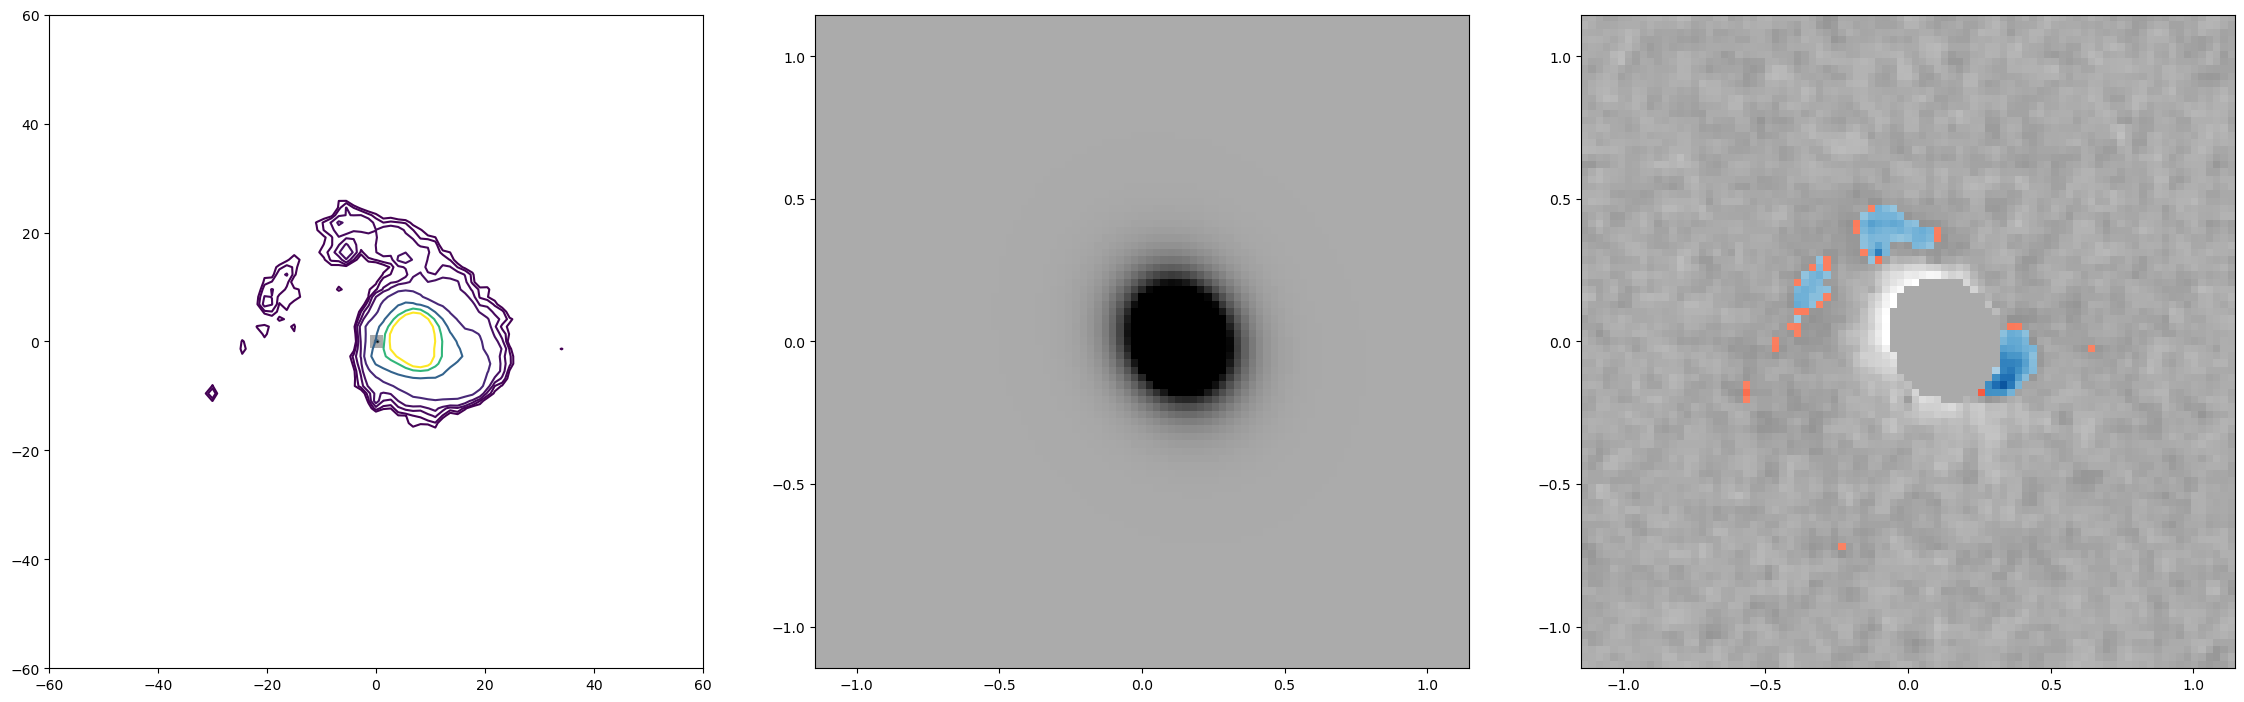

Filename: ../matched_filter/mf_data/mf_catalogs/26p5_2000/storm_2/mf_storm_2_d=34.3_a=170.0_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (89, 89)   float64   
z_fit_max: 20.809338634555004


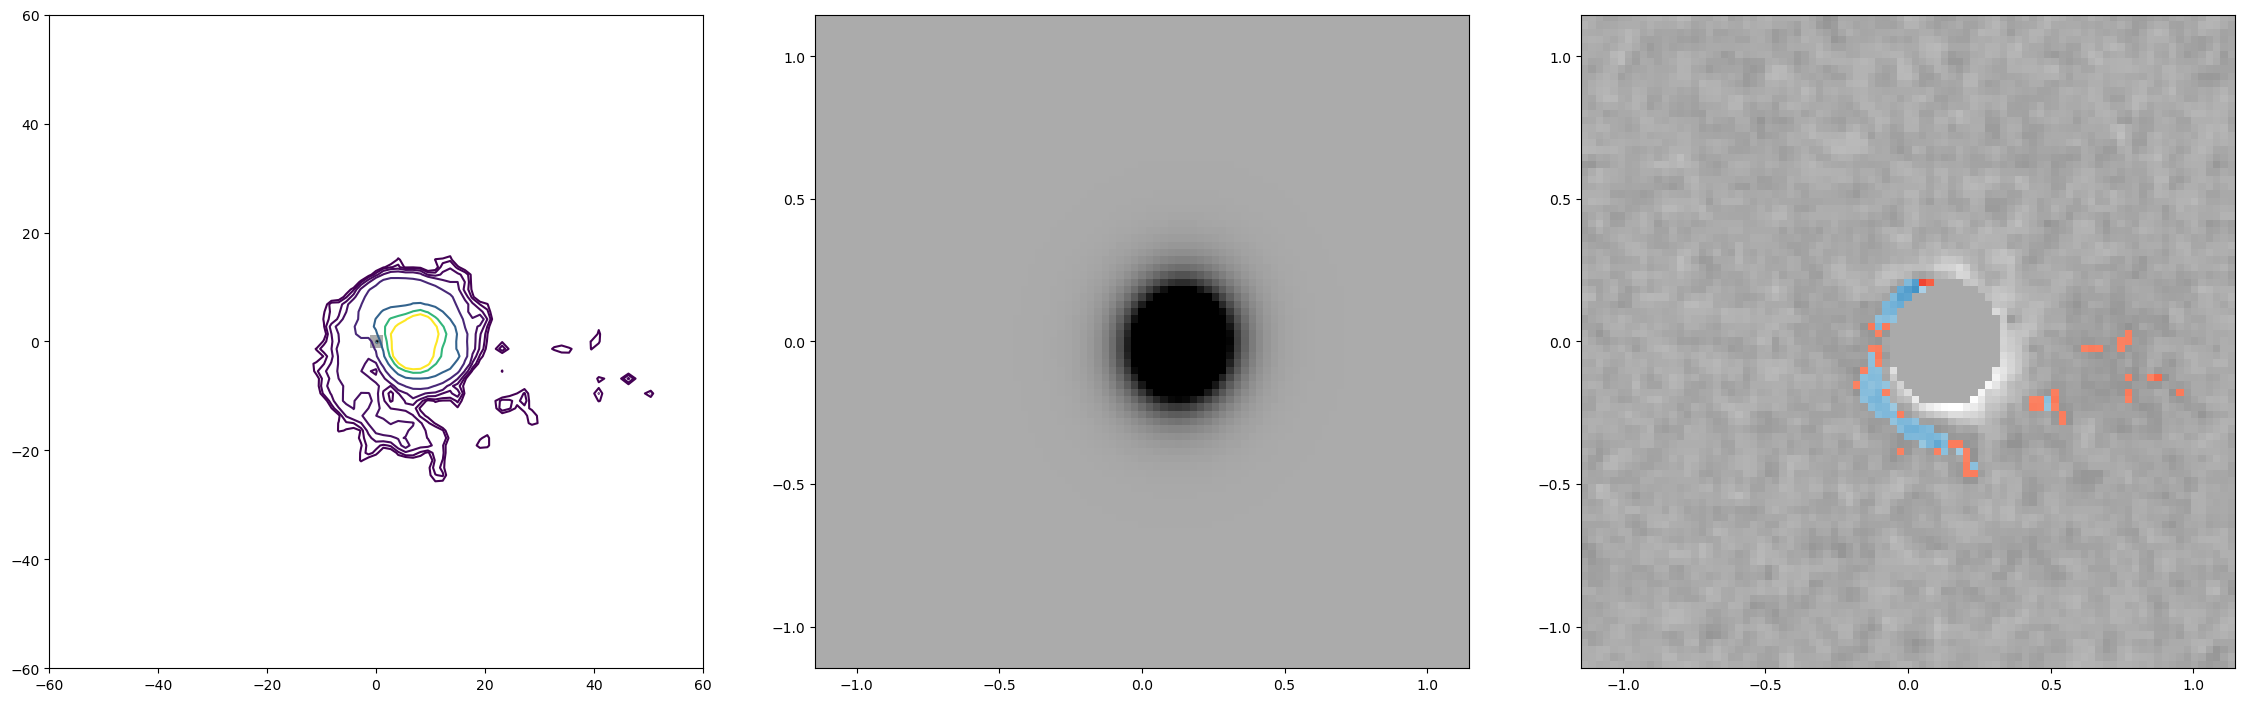

Filename: ../matched_filter/mf_data/mf_catalogs/26p5_2000/storm_2/mf_storm_2_d=38.5_a=32.5_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (89, 89)   float64   
z_fit_max: 23.52557088663106


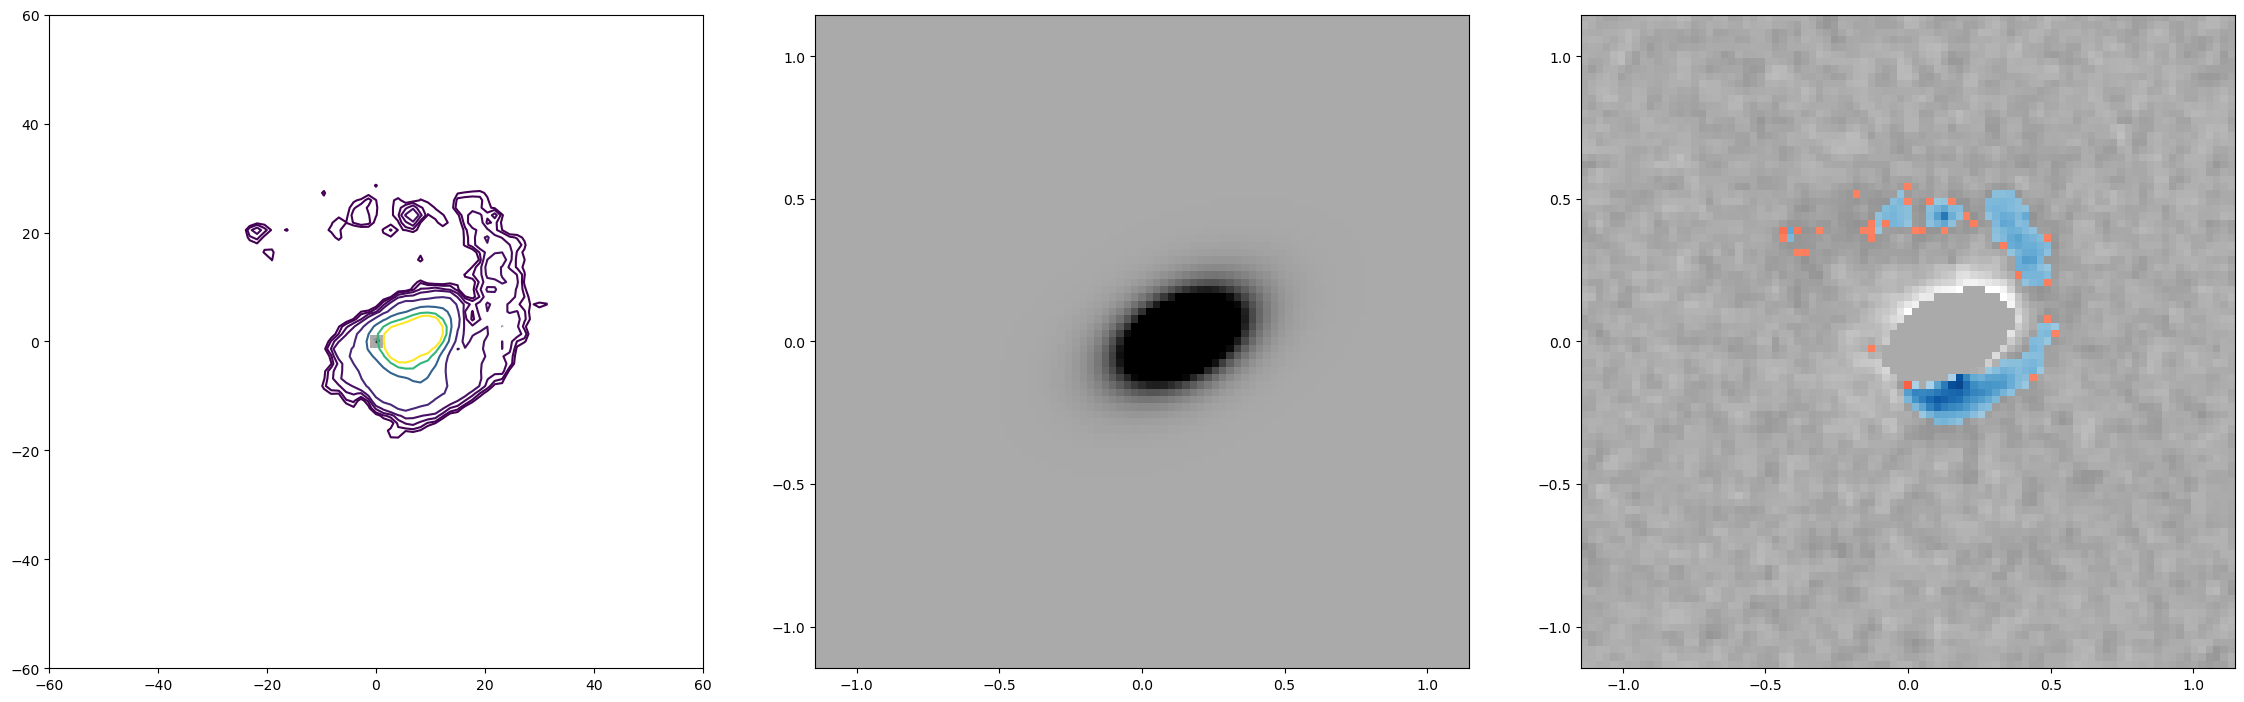

Filename: ../matched_filter/mf_data/mf_catalogs/26p5_2000/storm_2/mf_storm_2_d=42.3_a=255.0_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (89, 89)   float64   
z_fit_max: 21.933994676696347


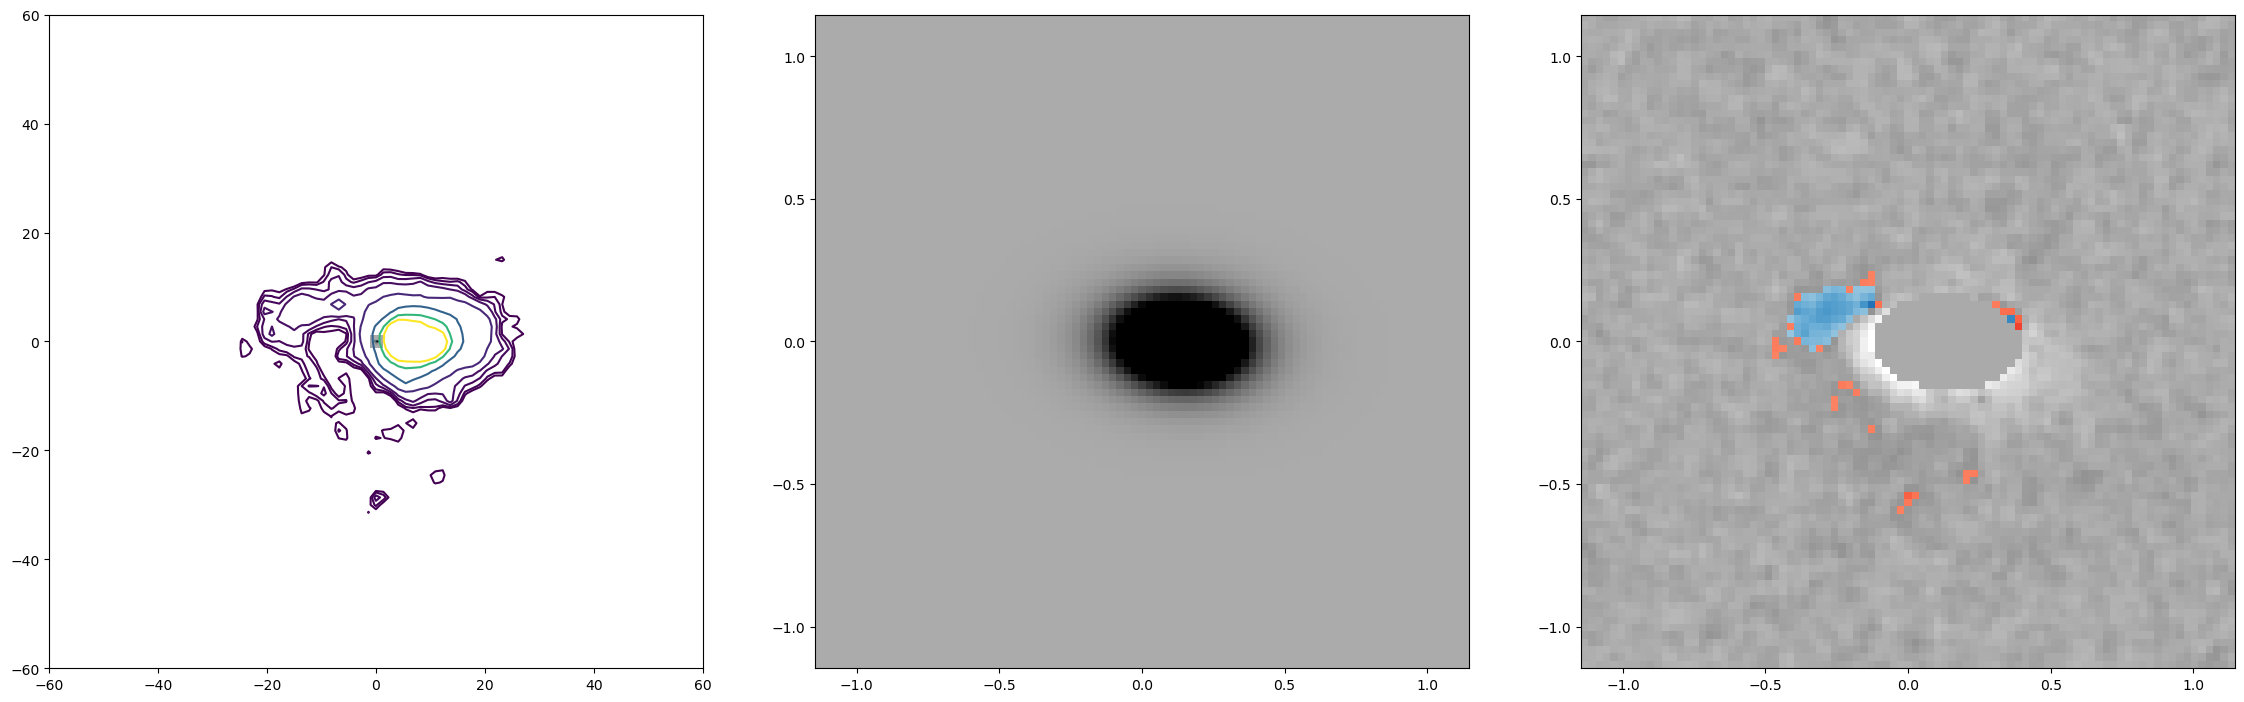

Filename: ../matched_filter/mf_data/mf_catalogs/26p5_2000/storm_2/mf_storm_2_d=45.9_a=117.4_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (89, 89)   float64   
z_fit_max: 26.043275360350556


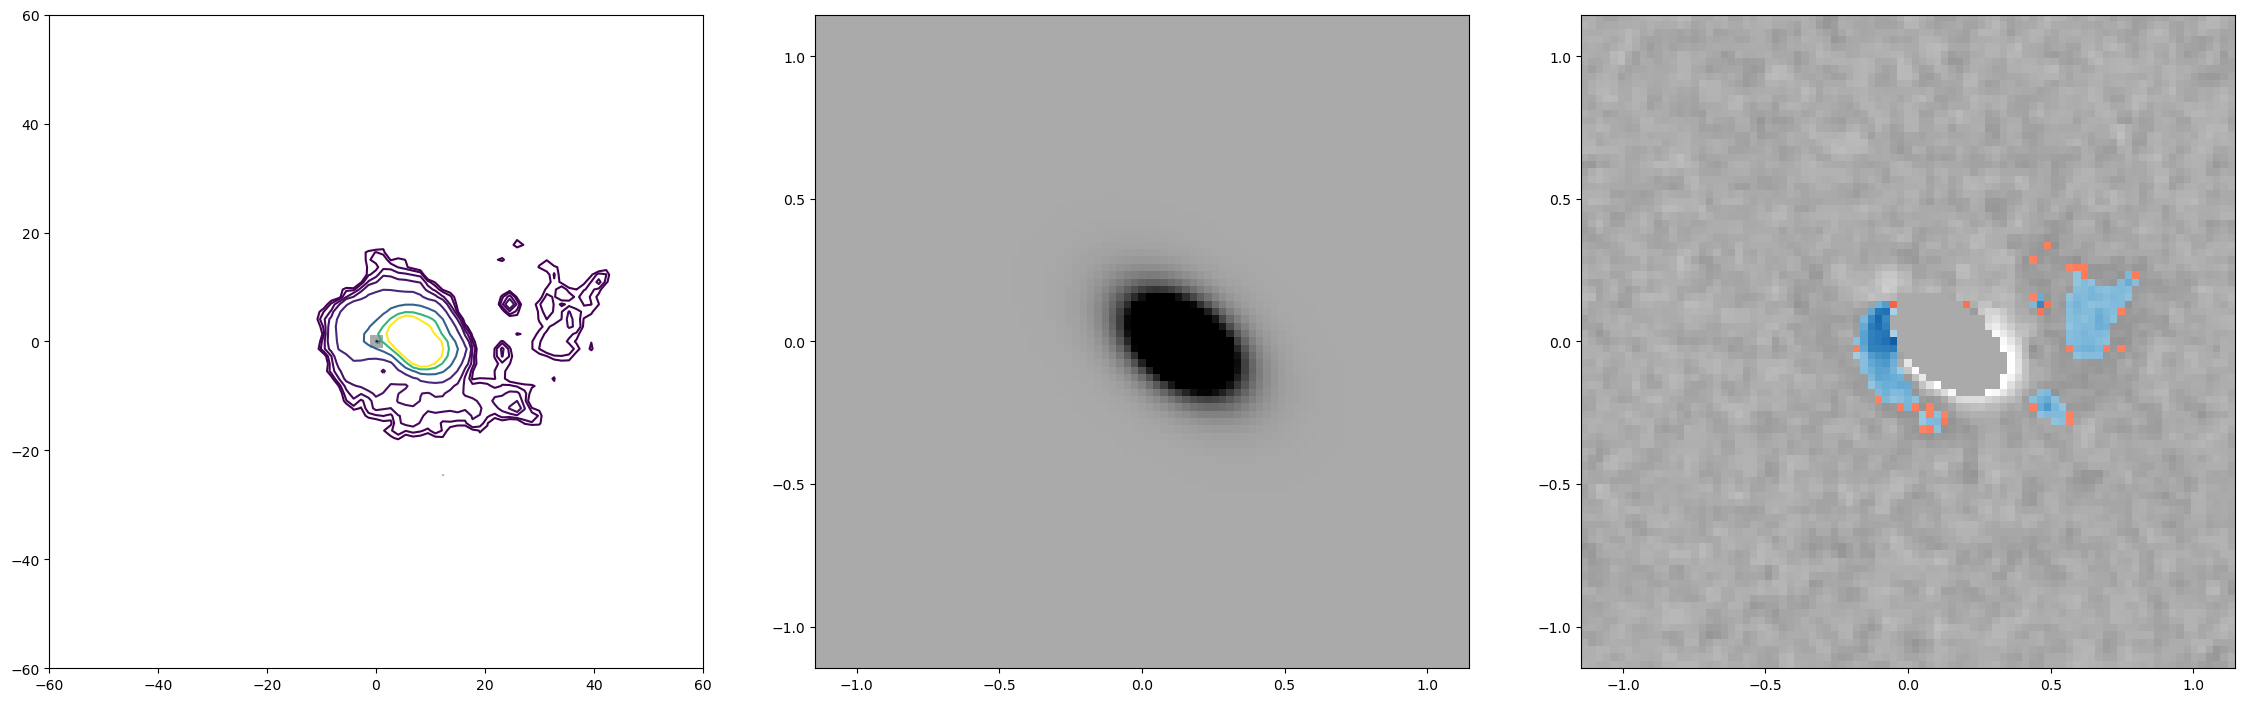

Filename: ../matched_filter/mf_data/mf_catalogs/26p5_2000/storm_2/mf_storm_2_d=49.3_a=339.9_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (89, 89)   float64   
z_fit_max: 27.263937486926523


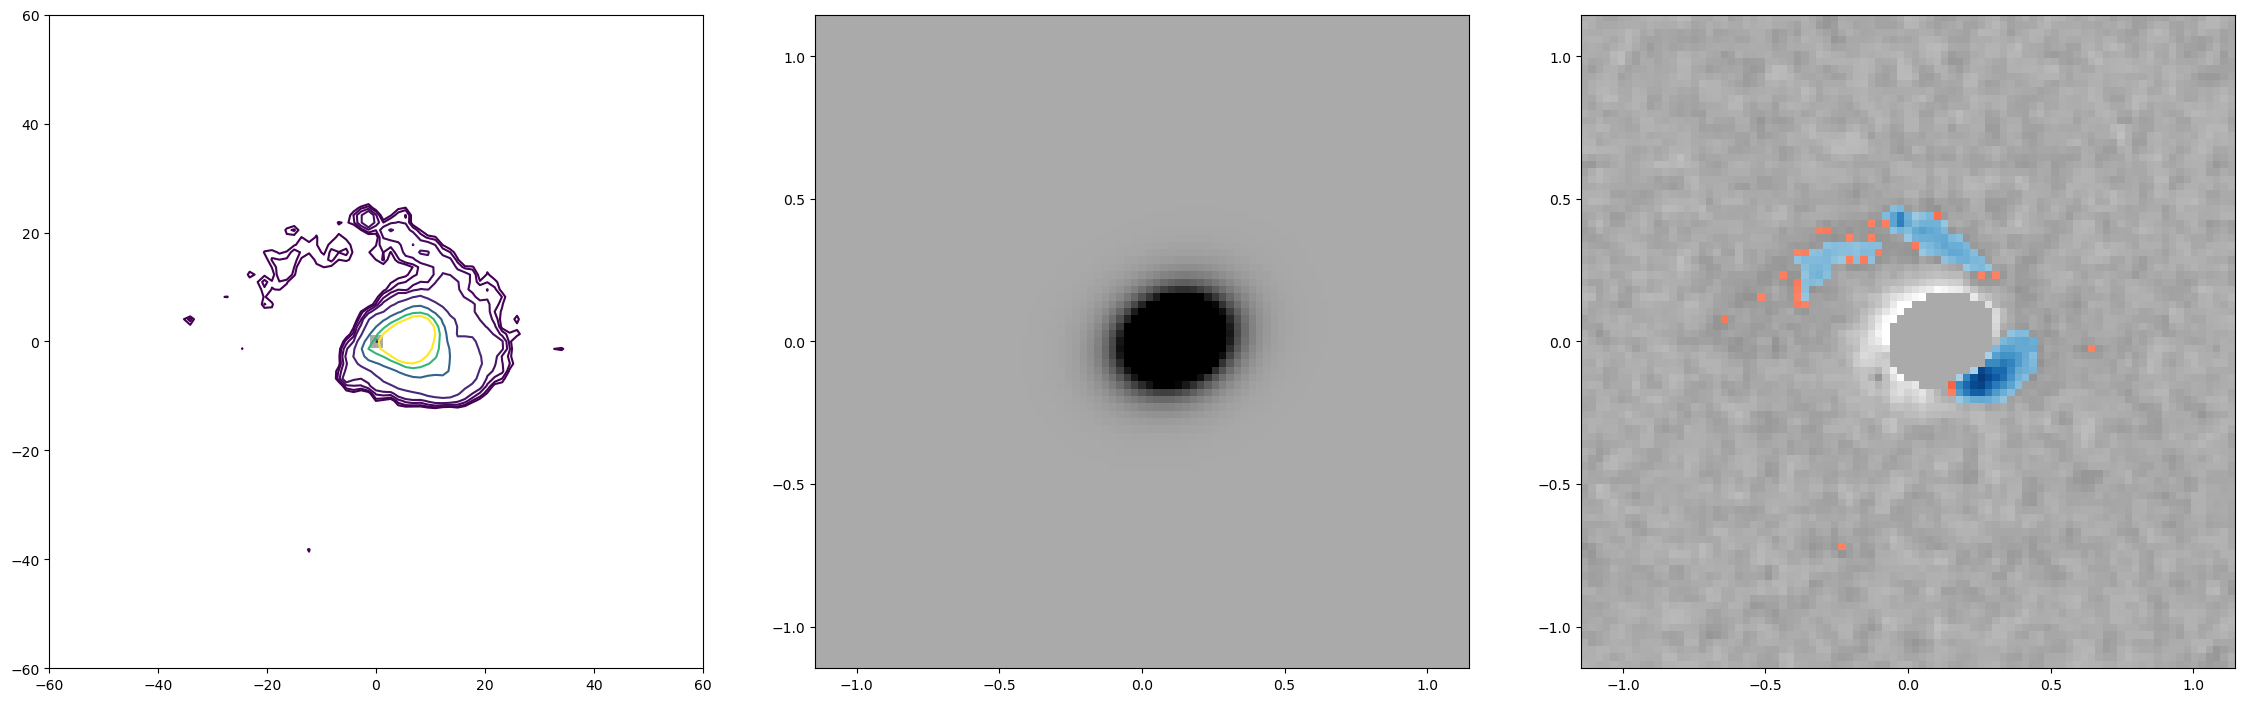

Filename: ../matched_filter/mf_data/mf_catalogs/26p5_2000/storm_2/mf_storm_2_d=52.5_a=202.4_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (89, 89)   float64   
z_fit_max: 23.841368222562465


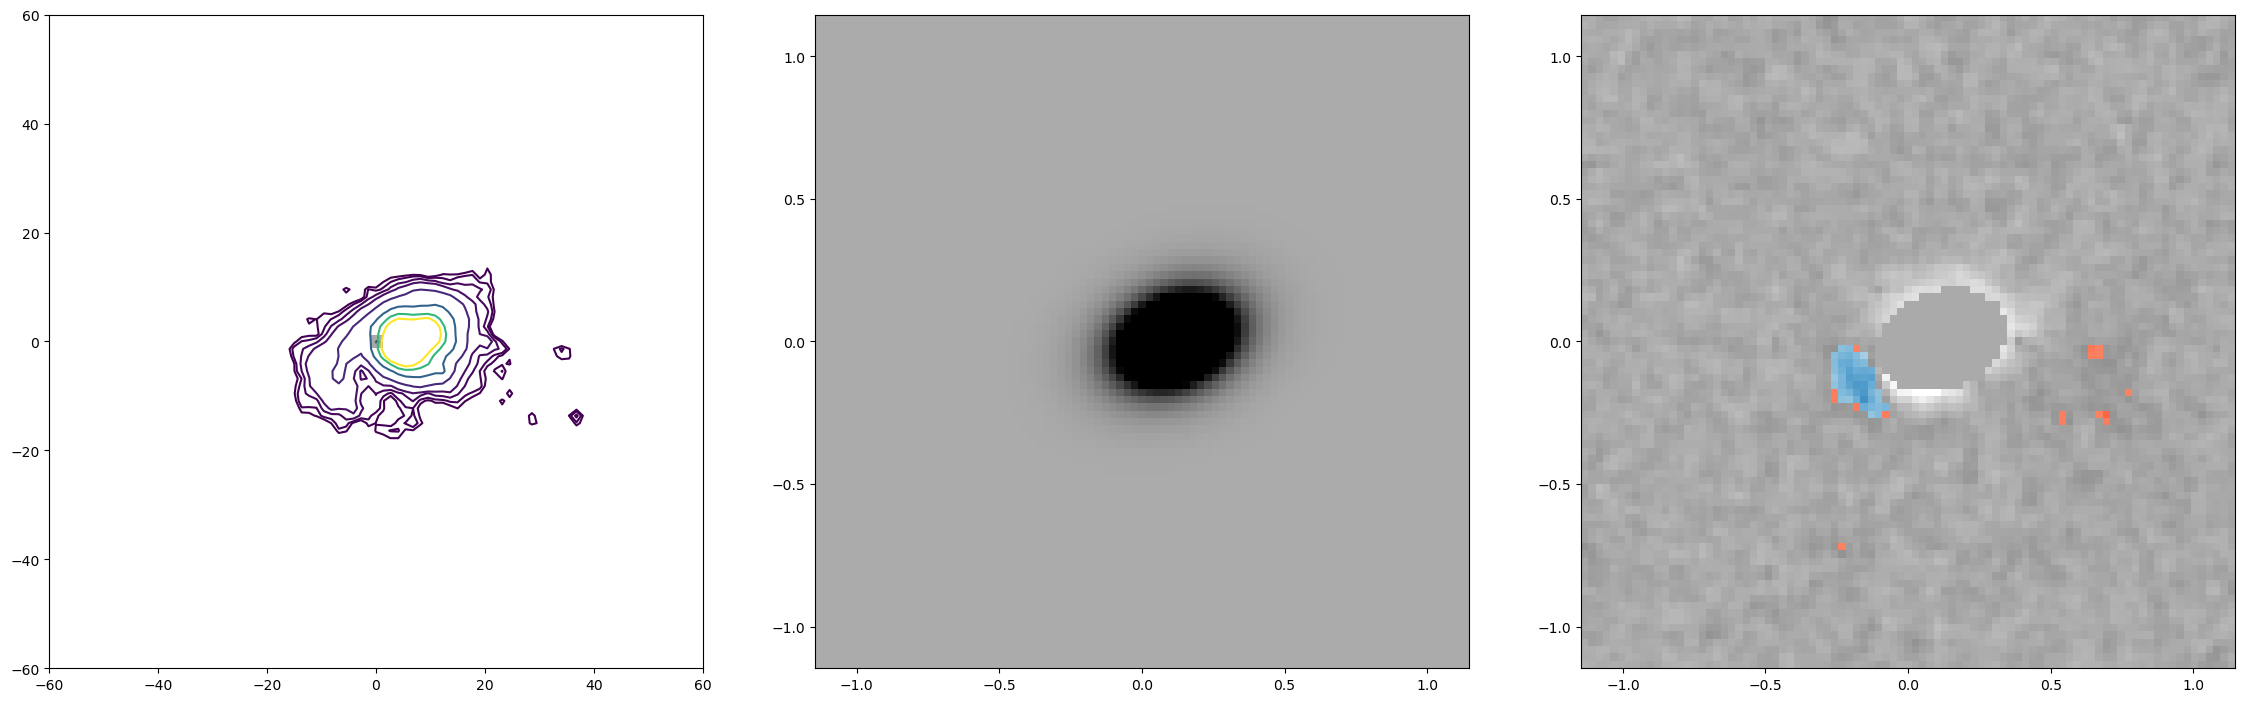

Filename: ../matched_filter/mf_data/mf_catalogs/26p5_2000/storm_2/mf_storm_2_d=55.6_a=64.9_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (89, 89)   float64   
z_fit_max: 31.333907311507627


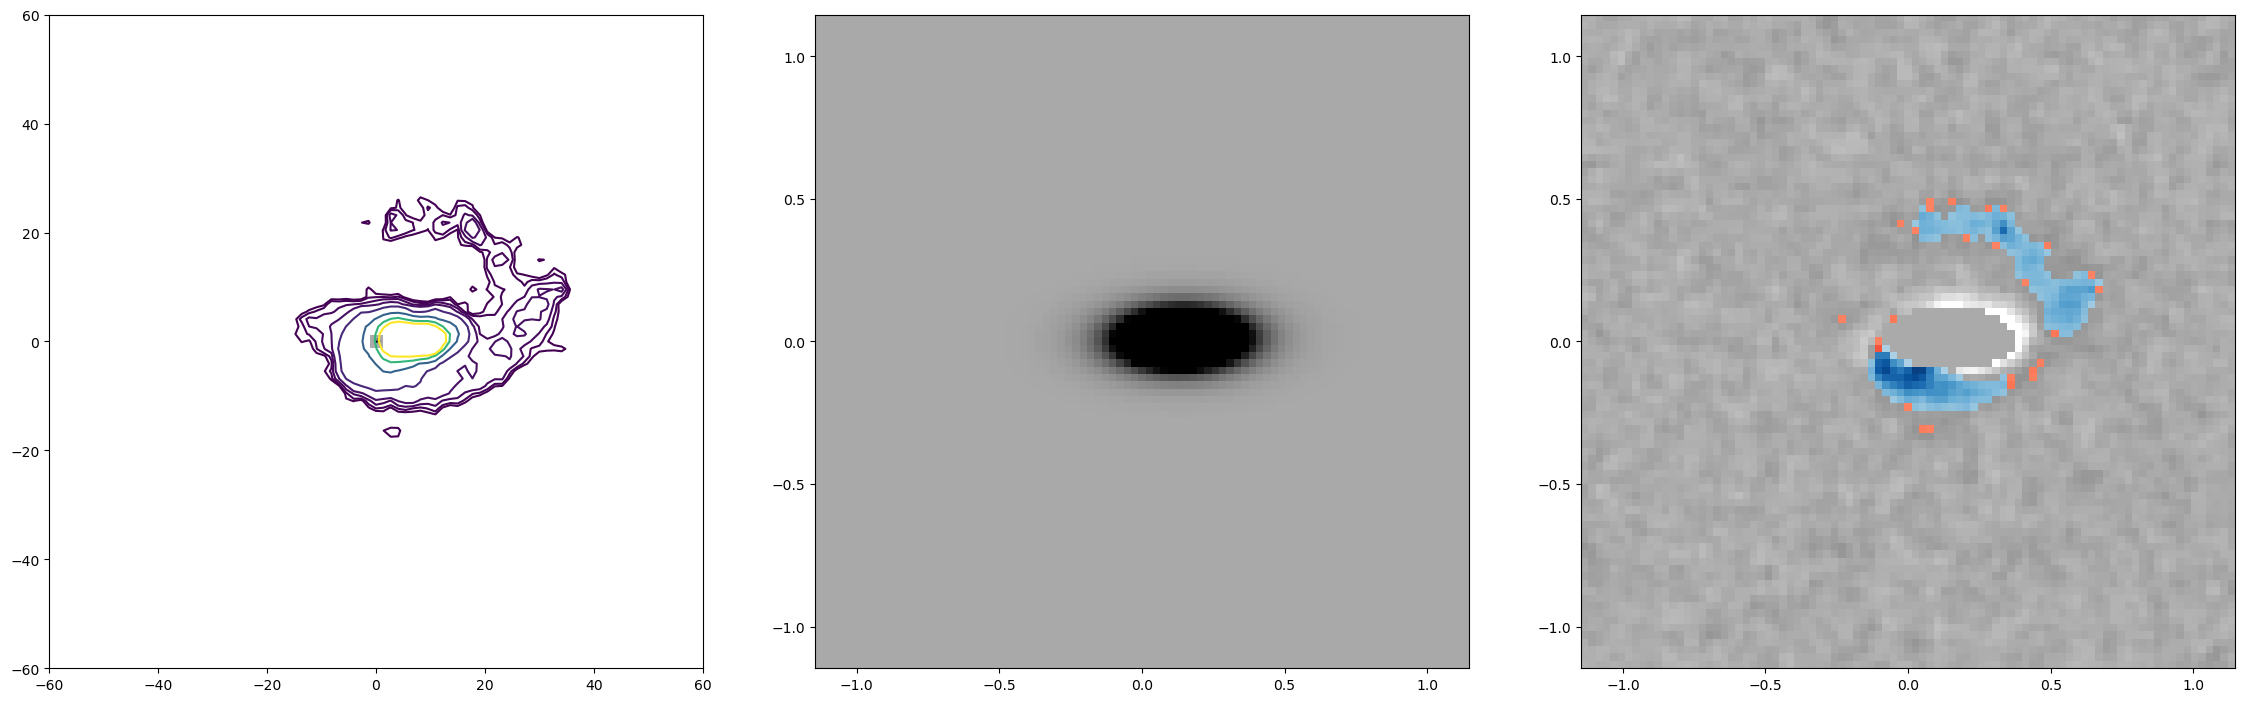

Filename: ../matched_filter/mf_data/mf_catalogs/26p5_2000/storm_2/mf_storm_2_d=58.6_a=287.4_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (89, 89)   float64   
z_fit_max: 27.266972932277454


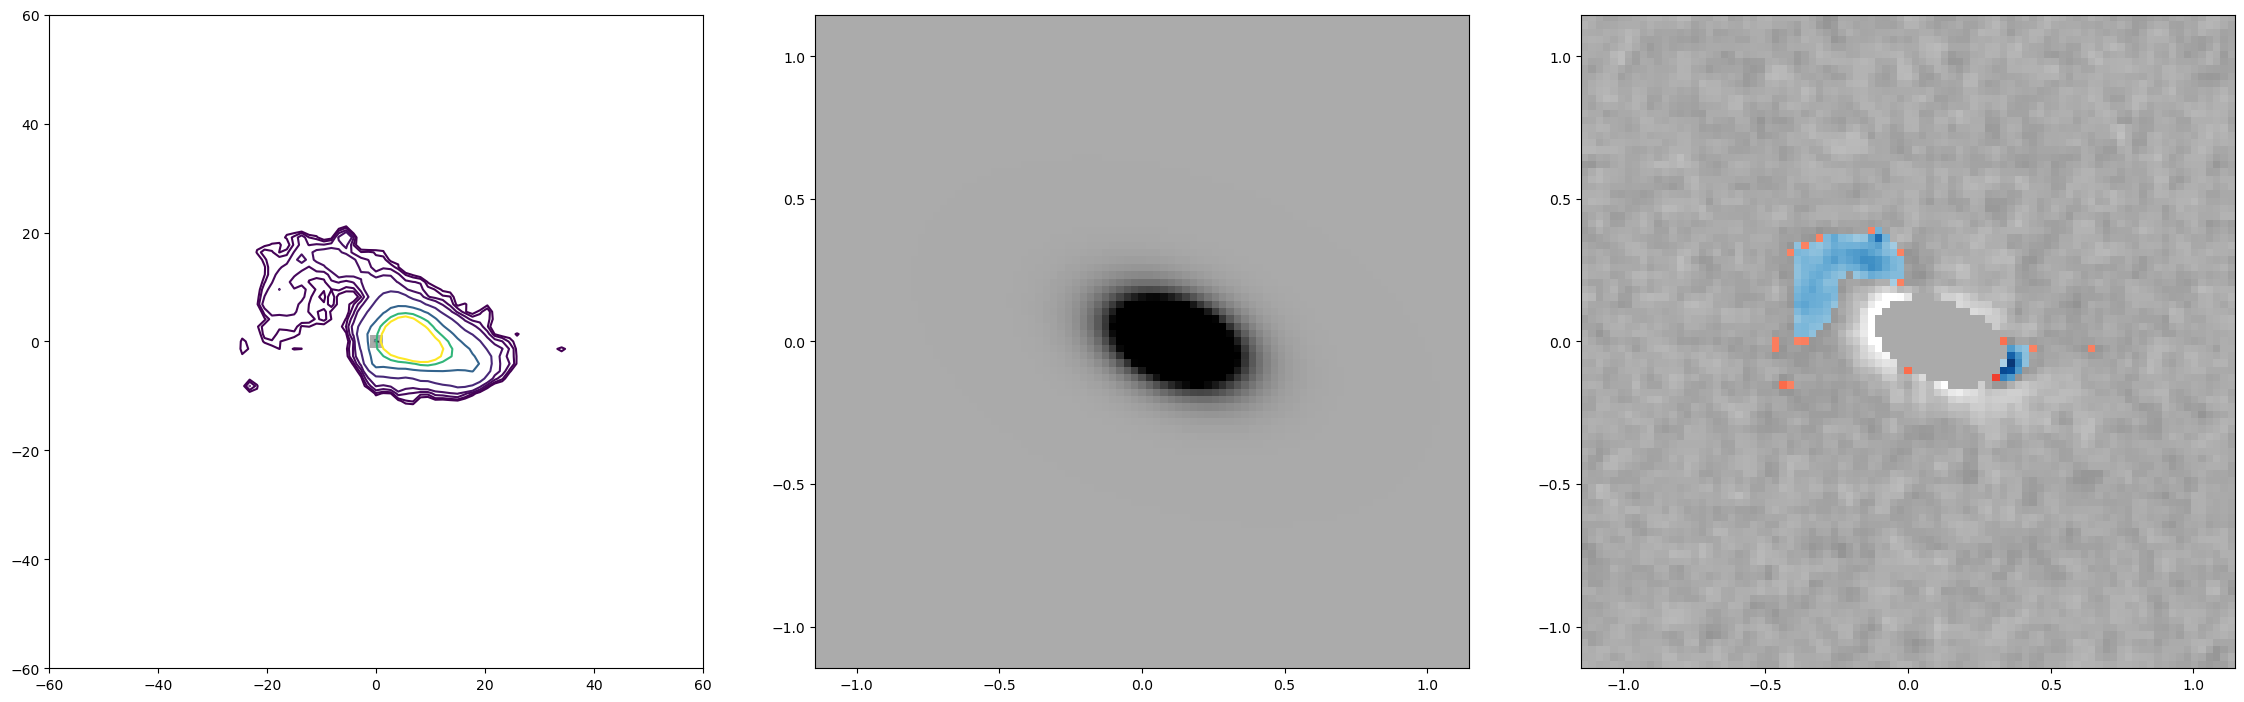

Filename: ../matched_filter/mf_data/mf_catalogs/26p5_2000/storm_2/mf_storm_2_d=61.4_a=149.9_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (89, 89)   float64   
z_fit_max: 32.82120908247631


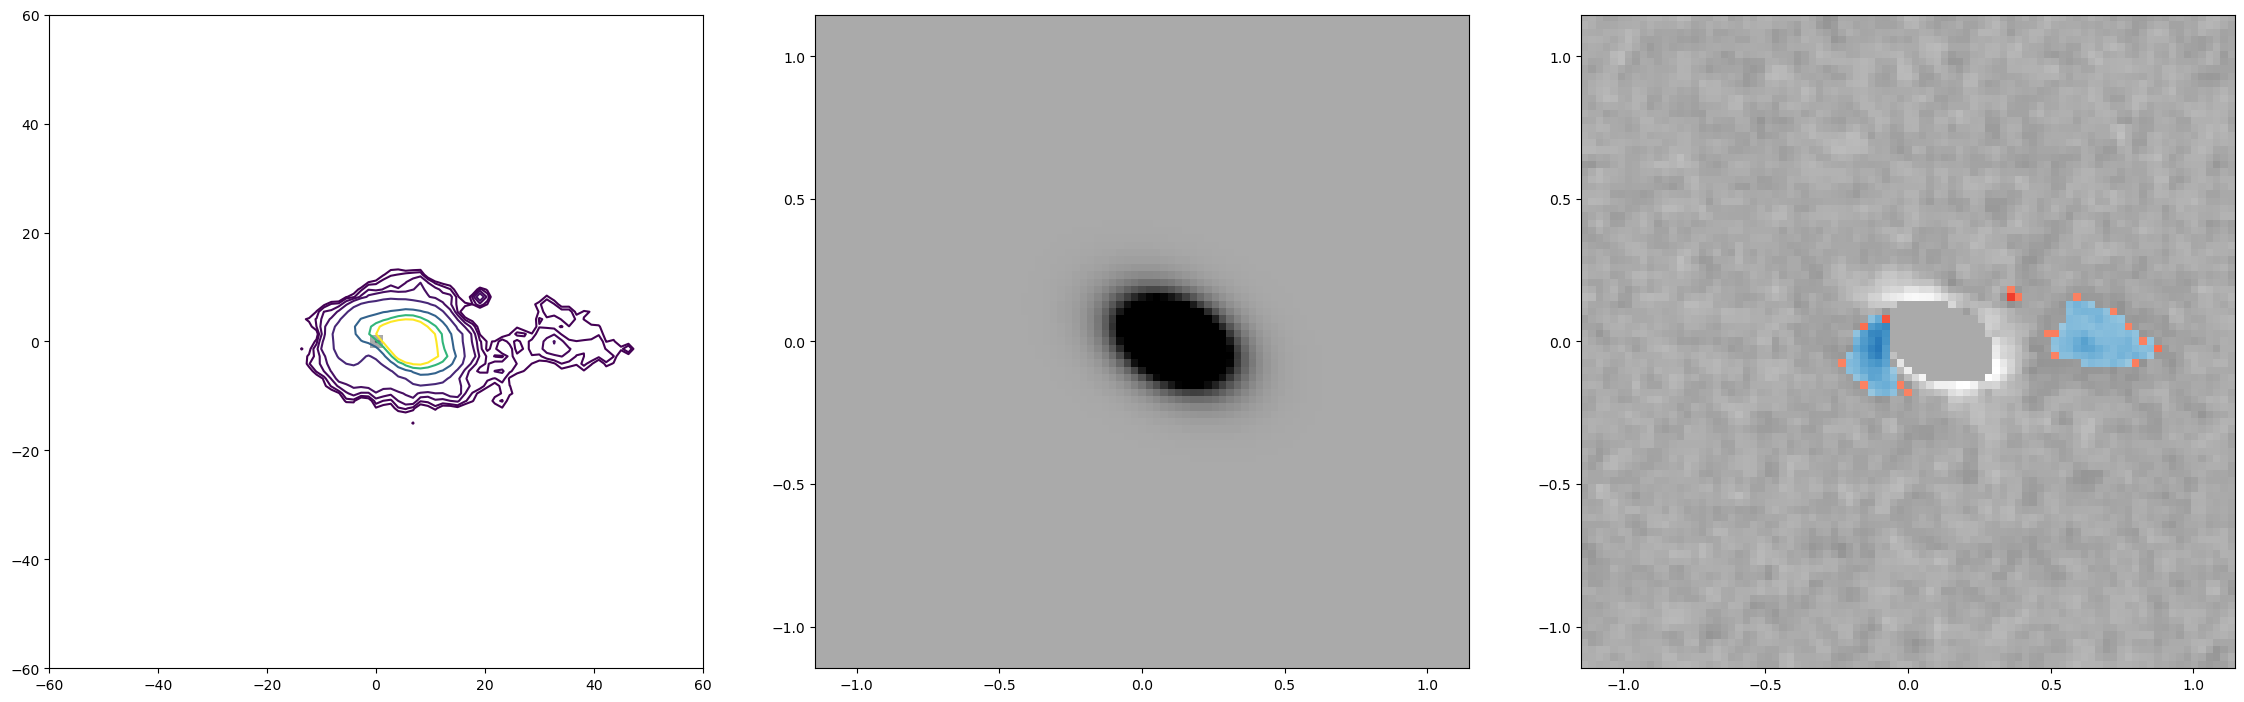

Filename: ../matched_filter/mf_data/mf_catalogs/26p5_2000/storm_2/mf_storm_2_d=64.2_a=12.4_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (89, 89)   float64   
z_fit_max: 38.34002015871706


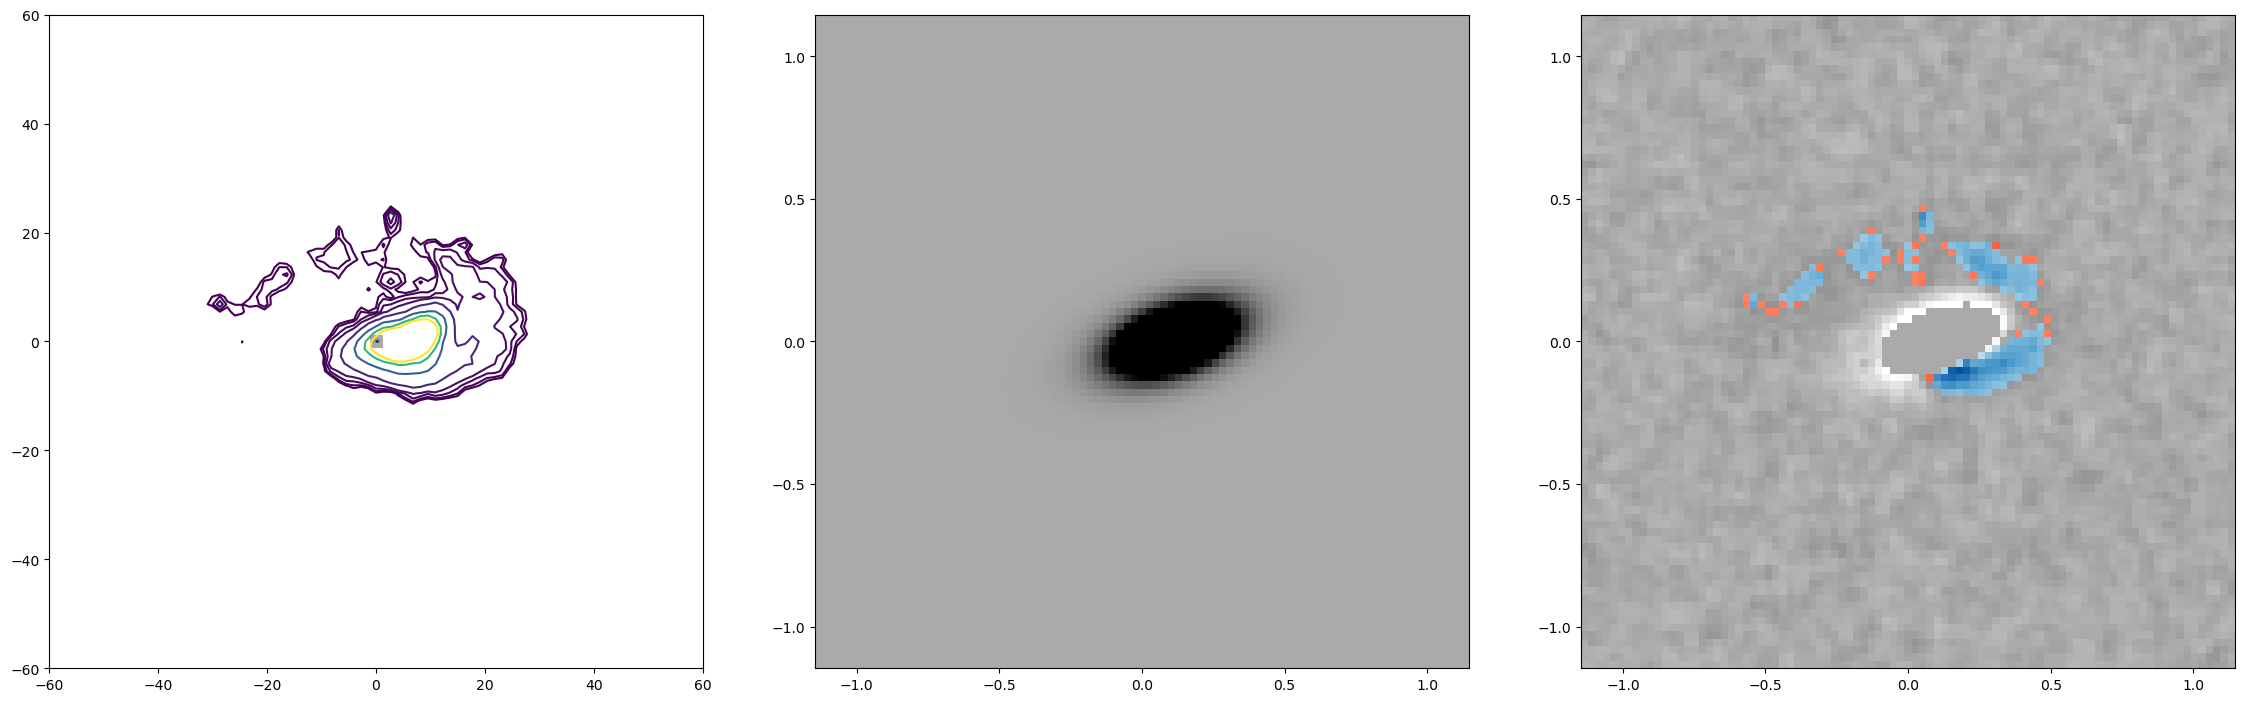

Filename: ../matched_filter/mf_data/mf_catalogs/26p5_2000/storm_2/mf_storm_2_d=67.0_a=234.9_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (89, 89)   float64   
z_fit_max: 29.499659602914864


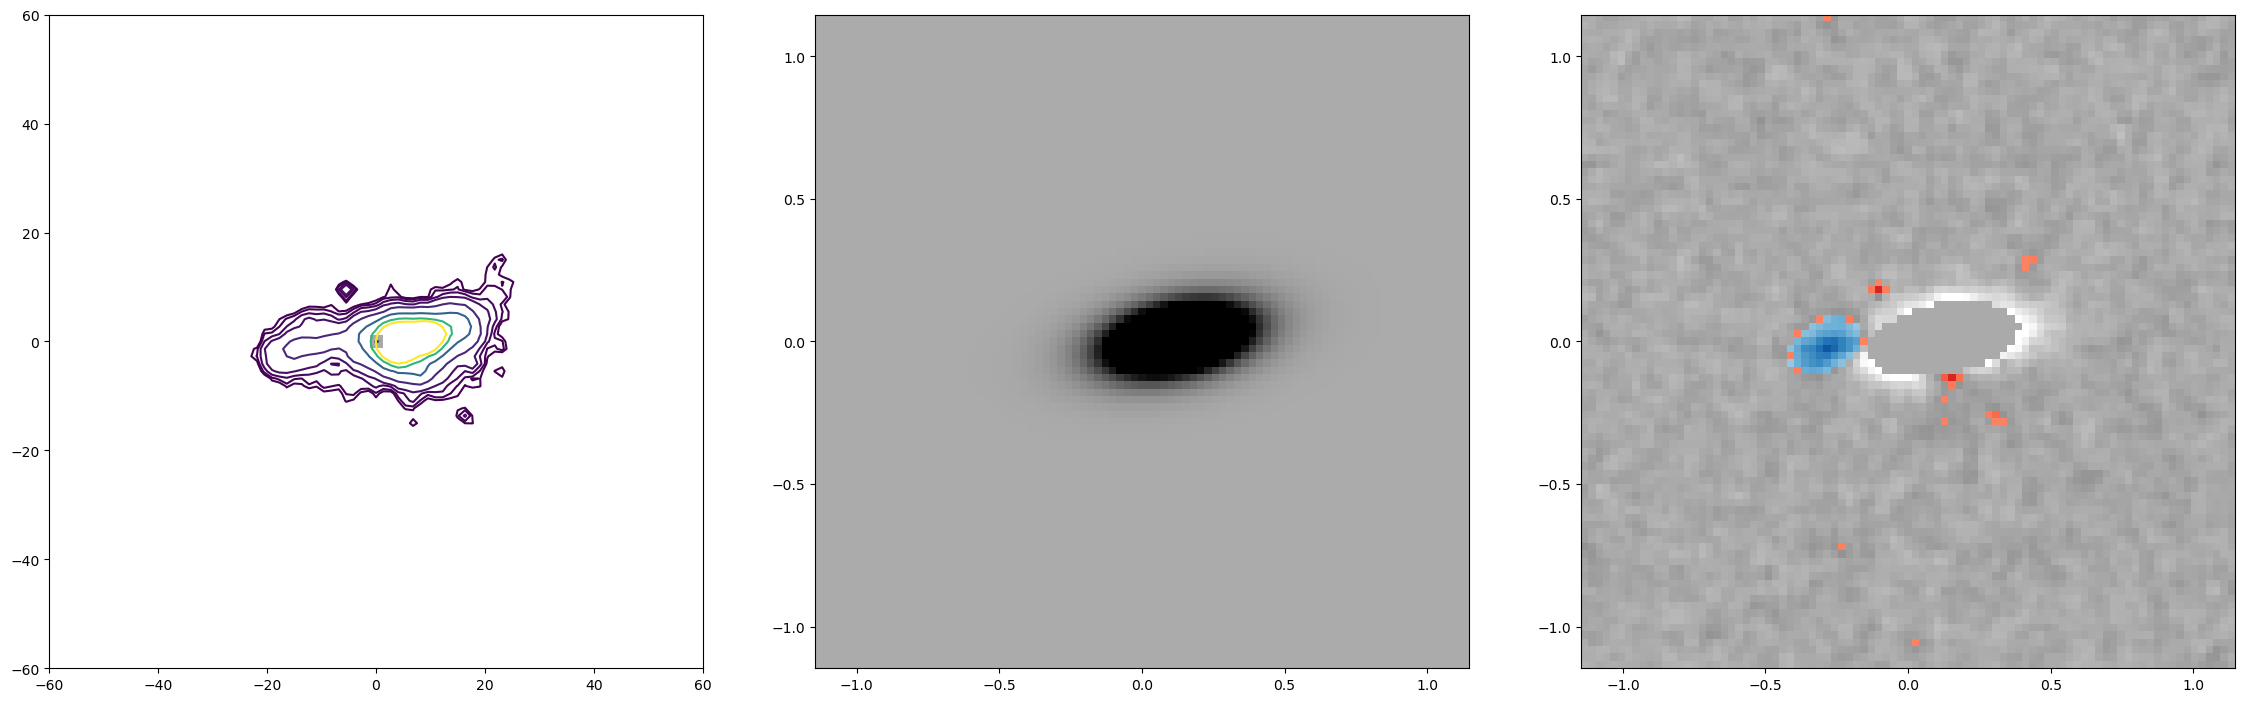

Filename: ../matched_filter/mf_data/mf_catalogs/26p5_2000/storm_2/mf_storm_2_d=69.6_a=97.4_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (89, 89)   float64   
z_fit_max: 40.116229201133336


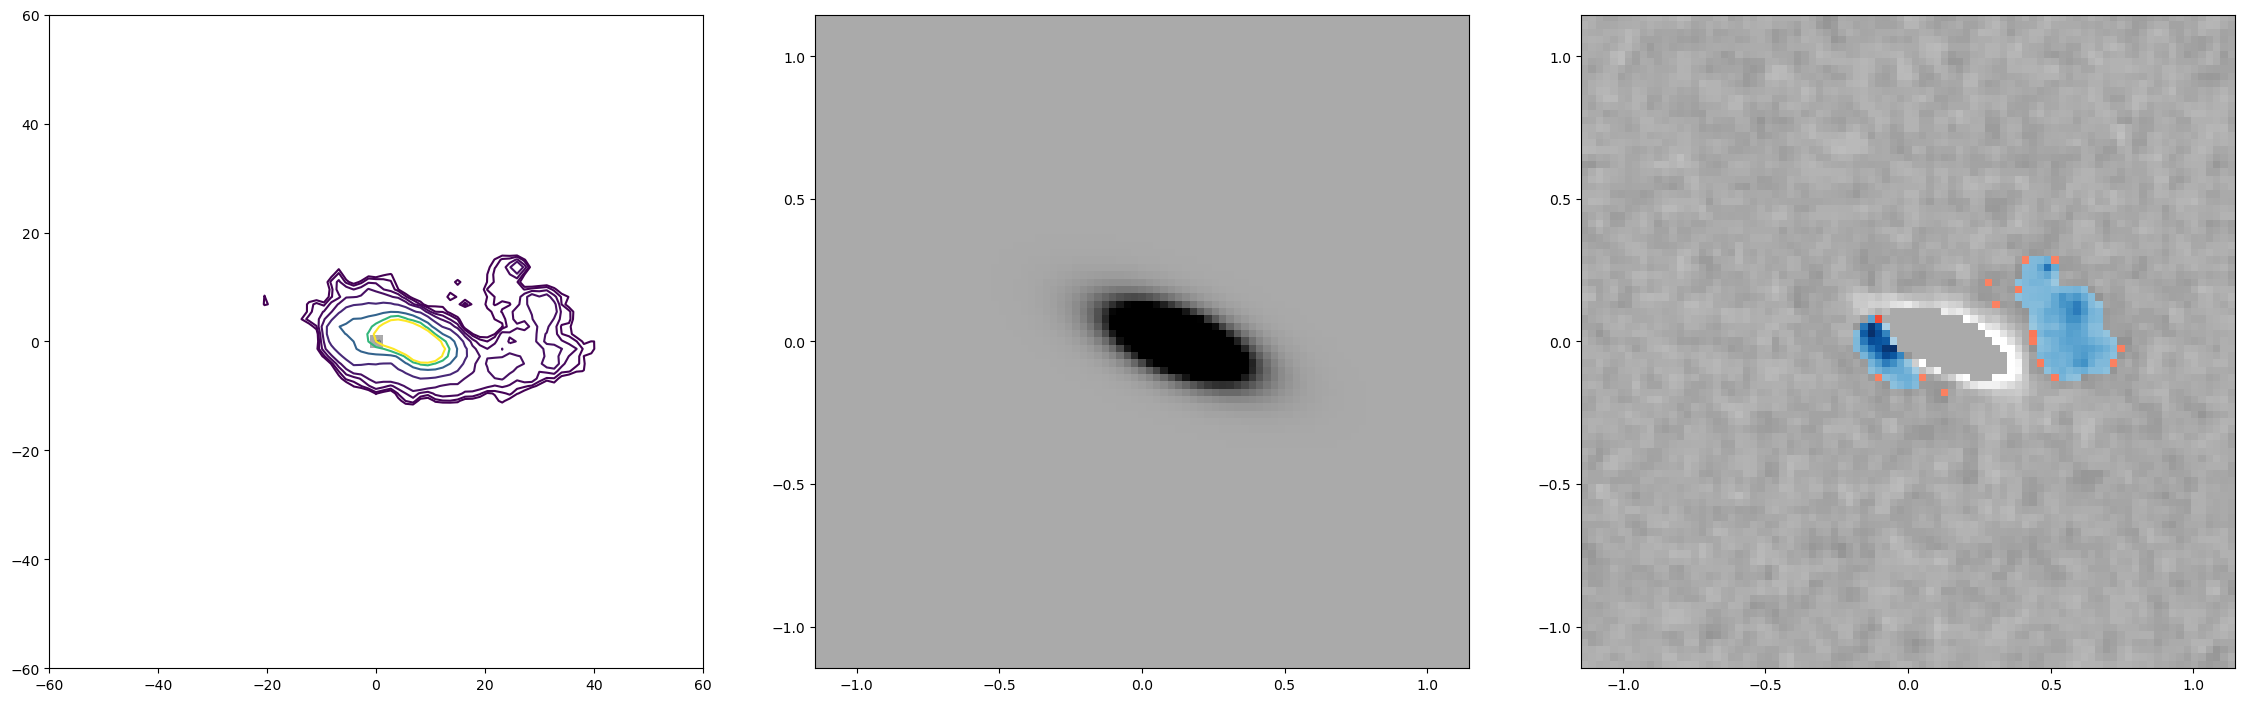

Filename: ../matched_filter/mf_data/mf_catalogs/26p5_2000/storm_2/mf_storm_2_d=72.3_a=319.9_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (89, 89)   float64   
z_fit_max: 43.04296527644856


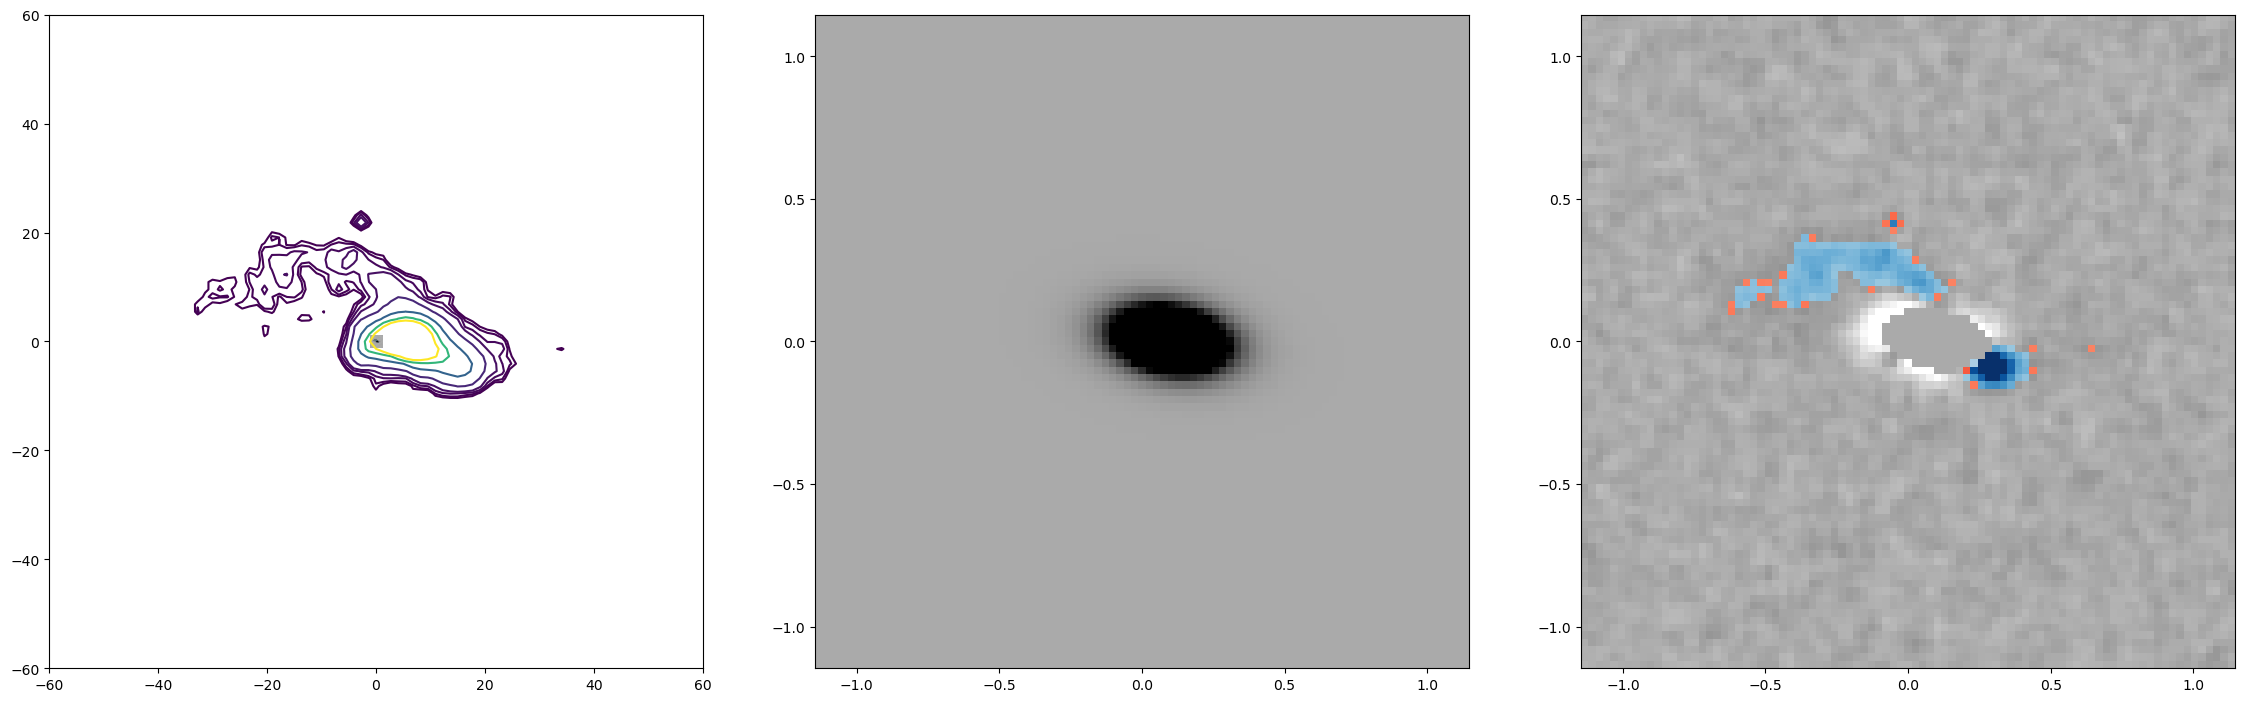

Filename: ../matched_filter/mf_data/mf_catalogs/26p5_2000/storm_2/mf_storm_2_d=74.9_a=182.4_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (89, 89)   float64   
z_fit_max: 39.53447535536264


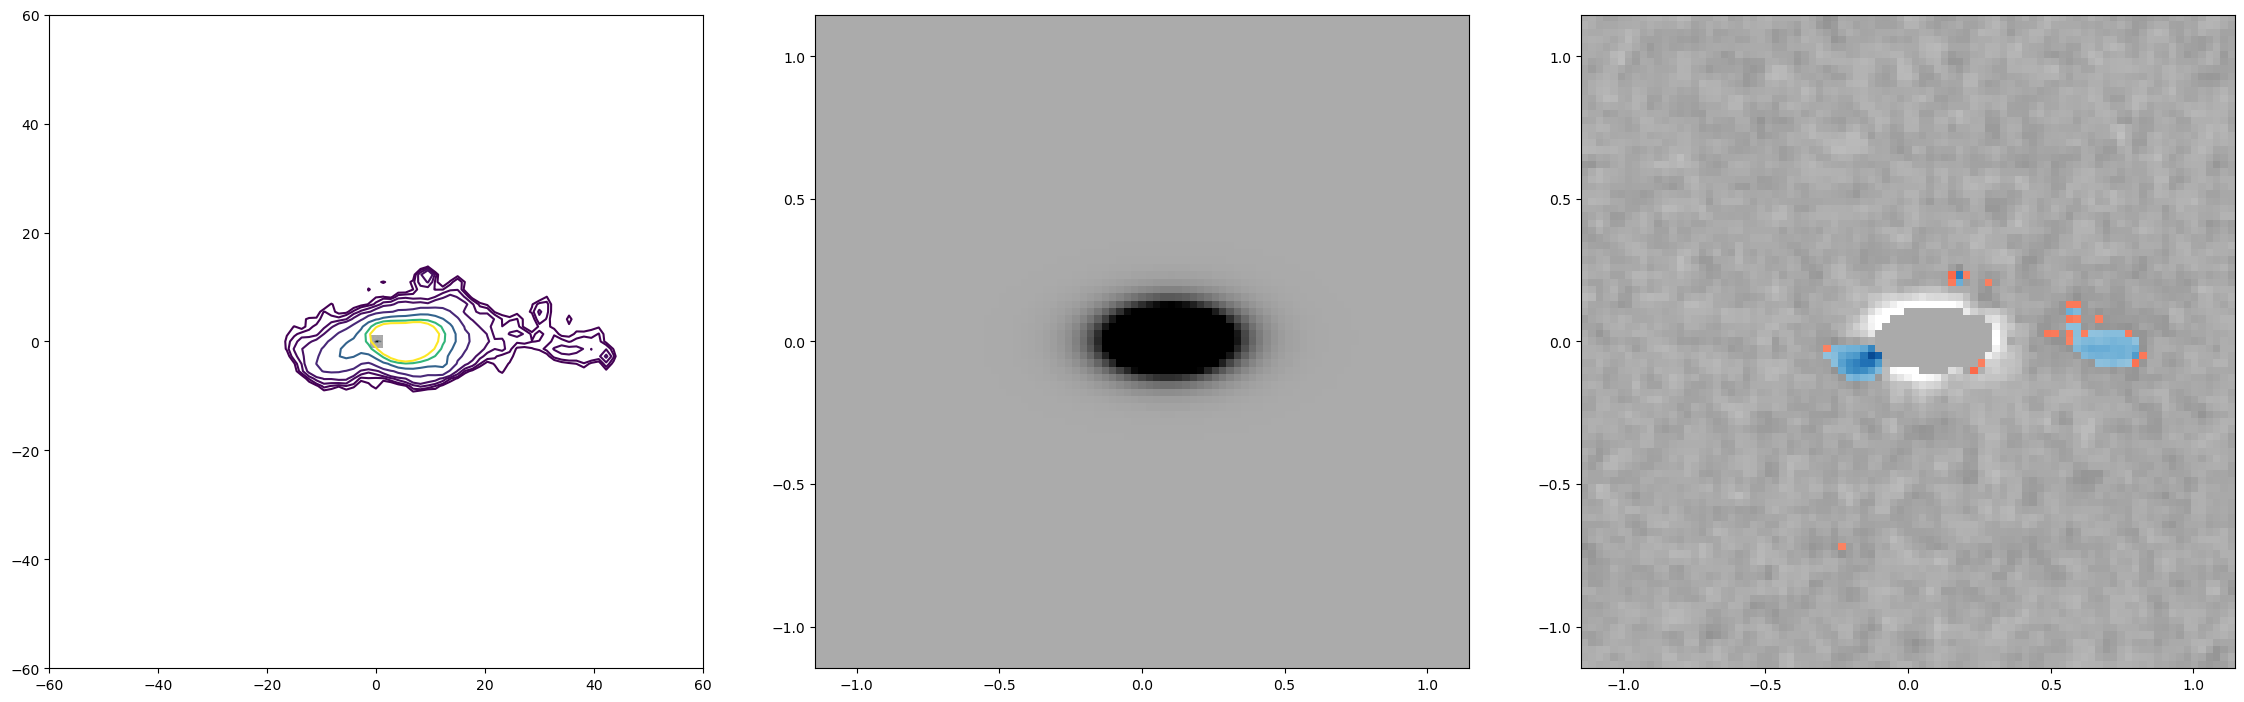

Filename: ../matched_filter/mf_data/mf_catalogs/26p5_2000/storm_2/mf_storm_2_d=77.4_a=44.9_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (89, 89)   float64   
z_fit_max: 42.2055703291021


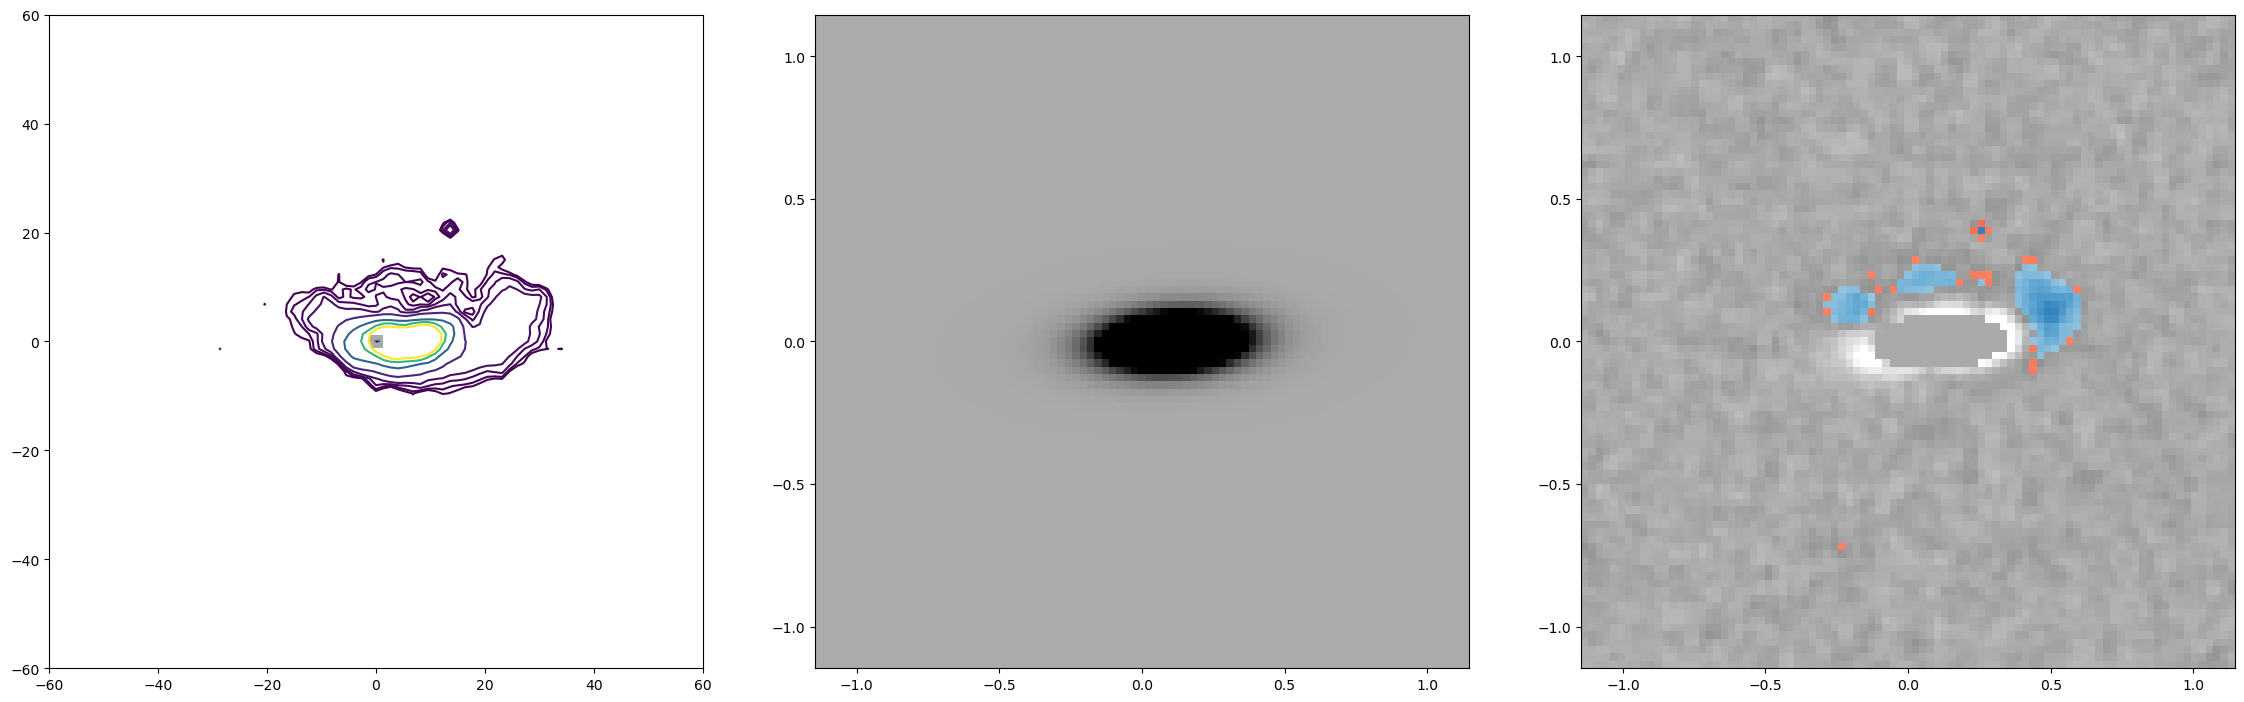

Filename: ../matched_filter/mf_data/mf_catalogs/26p5_2000/storm_2/mf_storm_2_d=80.0_a=267.4_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (89, 89)   float64   
z_fit_max: 37.76063642647431


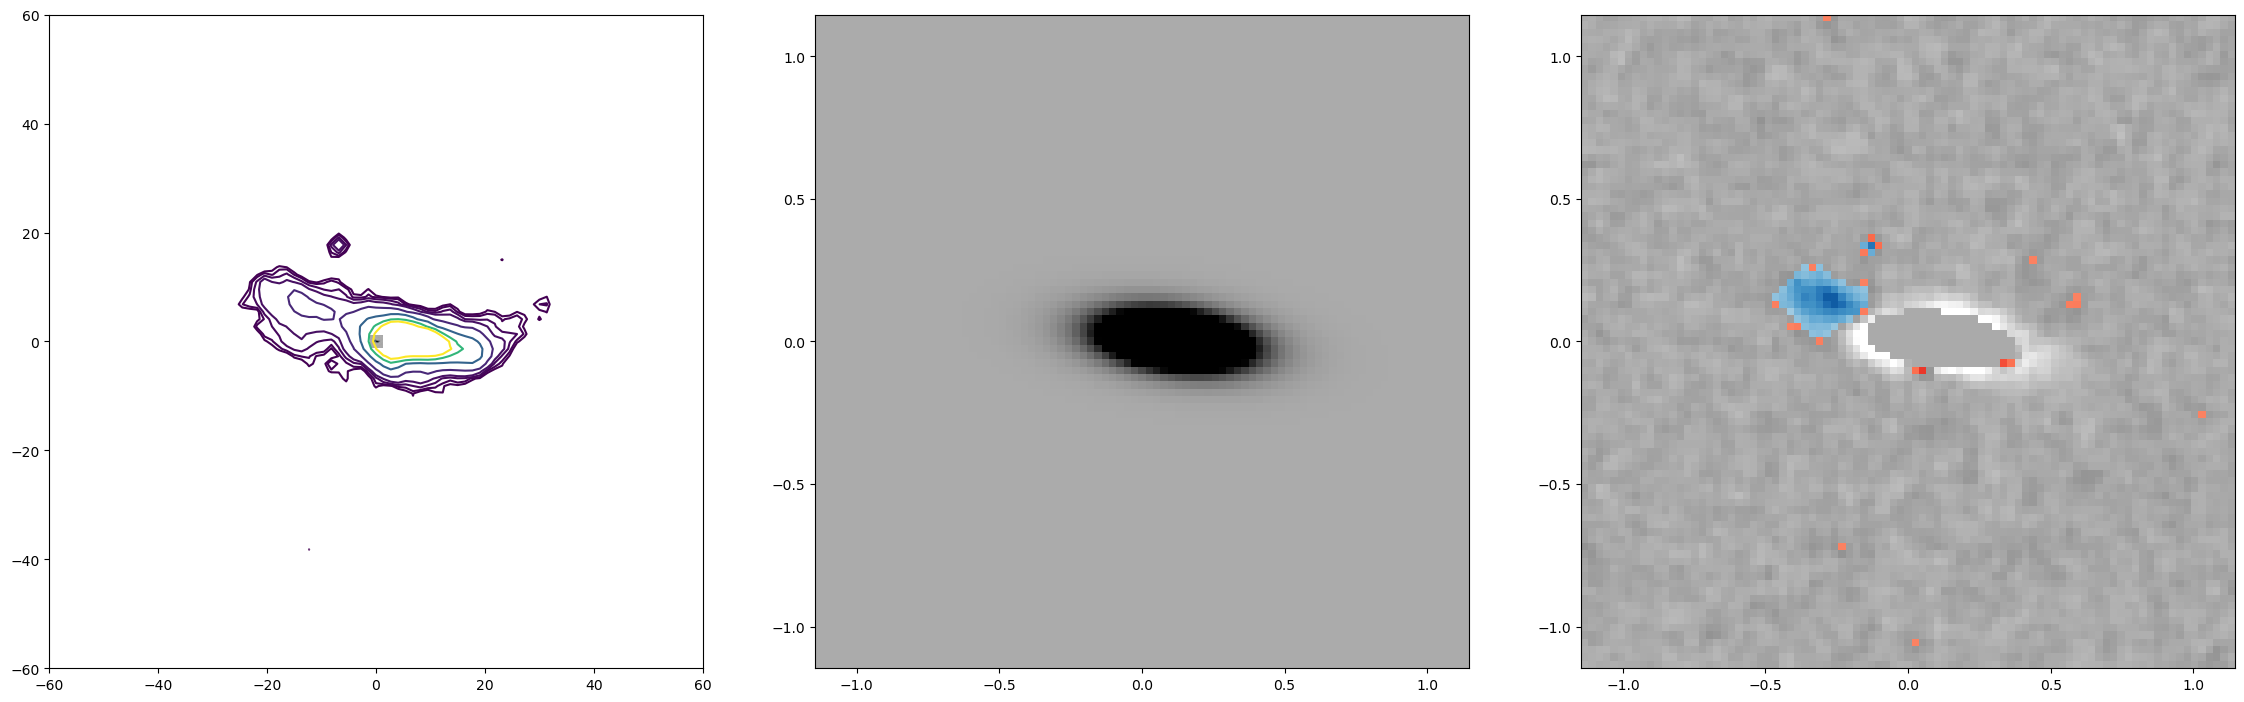

Filename: ../matched_filter/mf_data/mf_catalogs/26p5_2000/storm_2/mf_storm_2_d=82.5_a=129.8_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (89, 89)   float64   
z_fit_max: 46.04778064206445


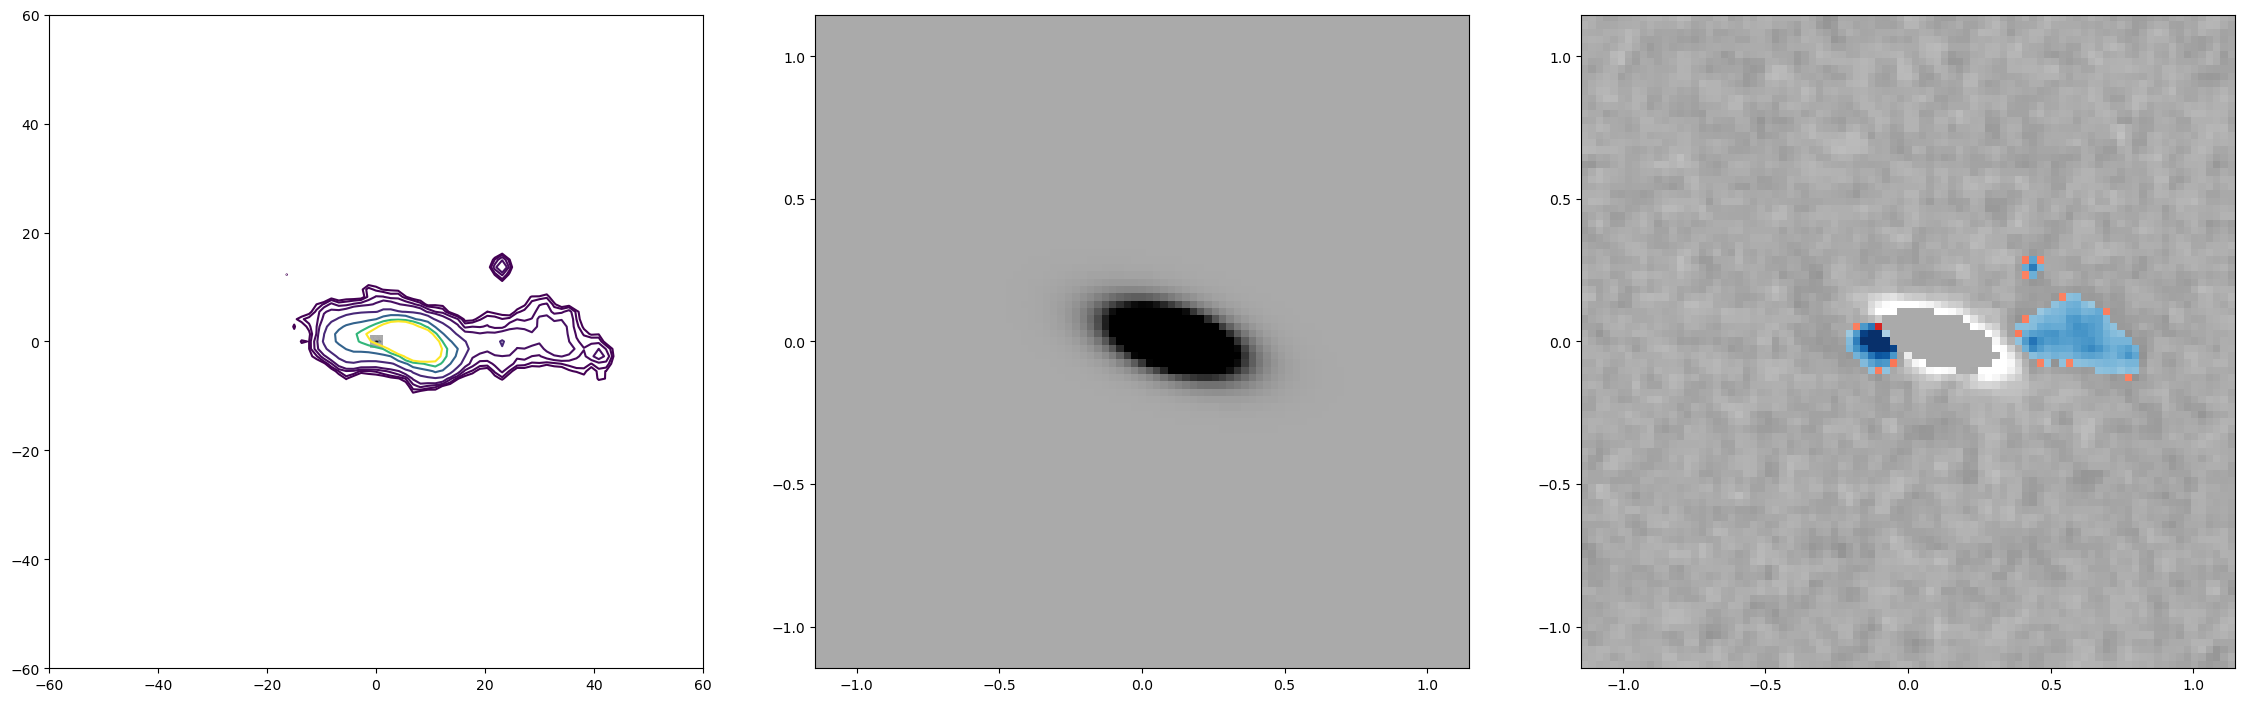

Filename: ../matched_filter/mf_data/mf_catalogs/26p5_2000/storm_2/mf_storm_2_d=85.0_a=352.3_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (89, 89)   float64   
z_fit_max: 49.998320909193644


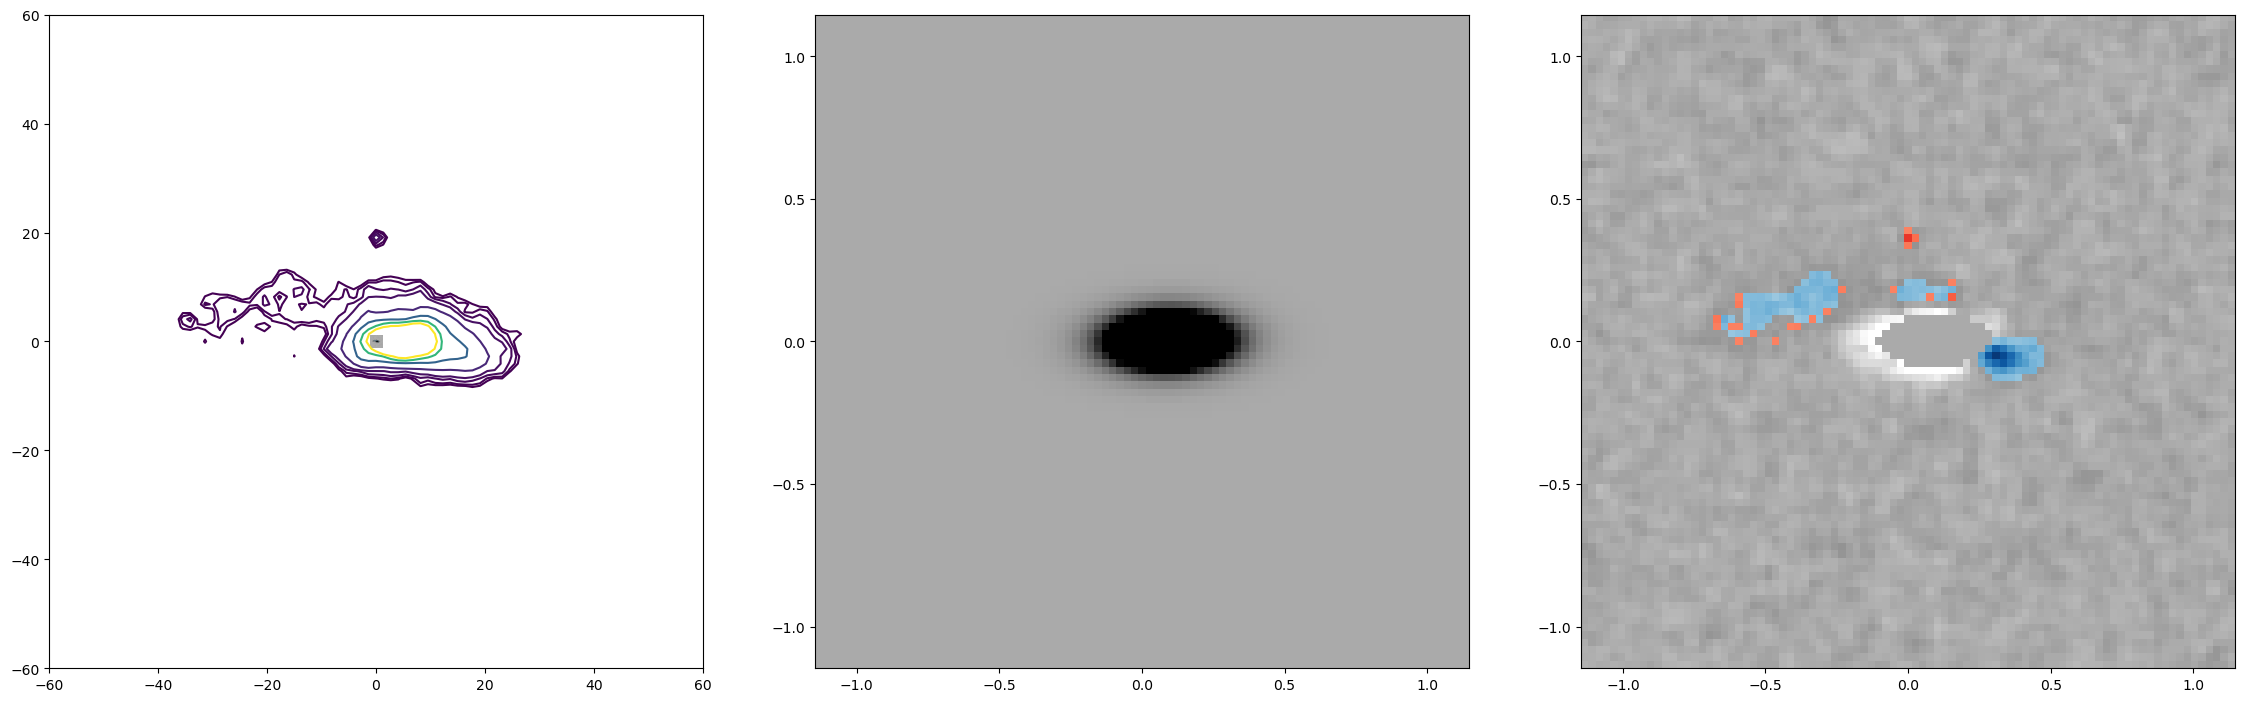

Filename: ../matched_filter/mf_data/mf_catalogs/26p5_2000/storm_2/mf_storm_2_d=87.5_a=214.8_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (89, 89)   float64   
z_fit_max: 45.32994585253781


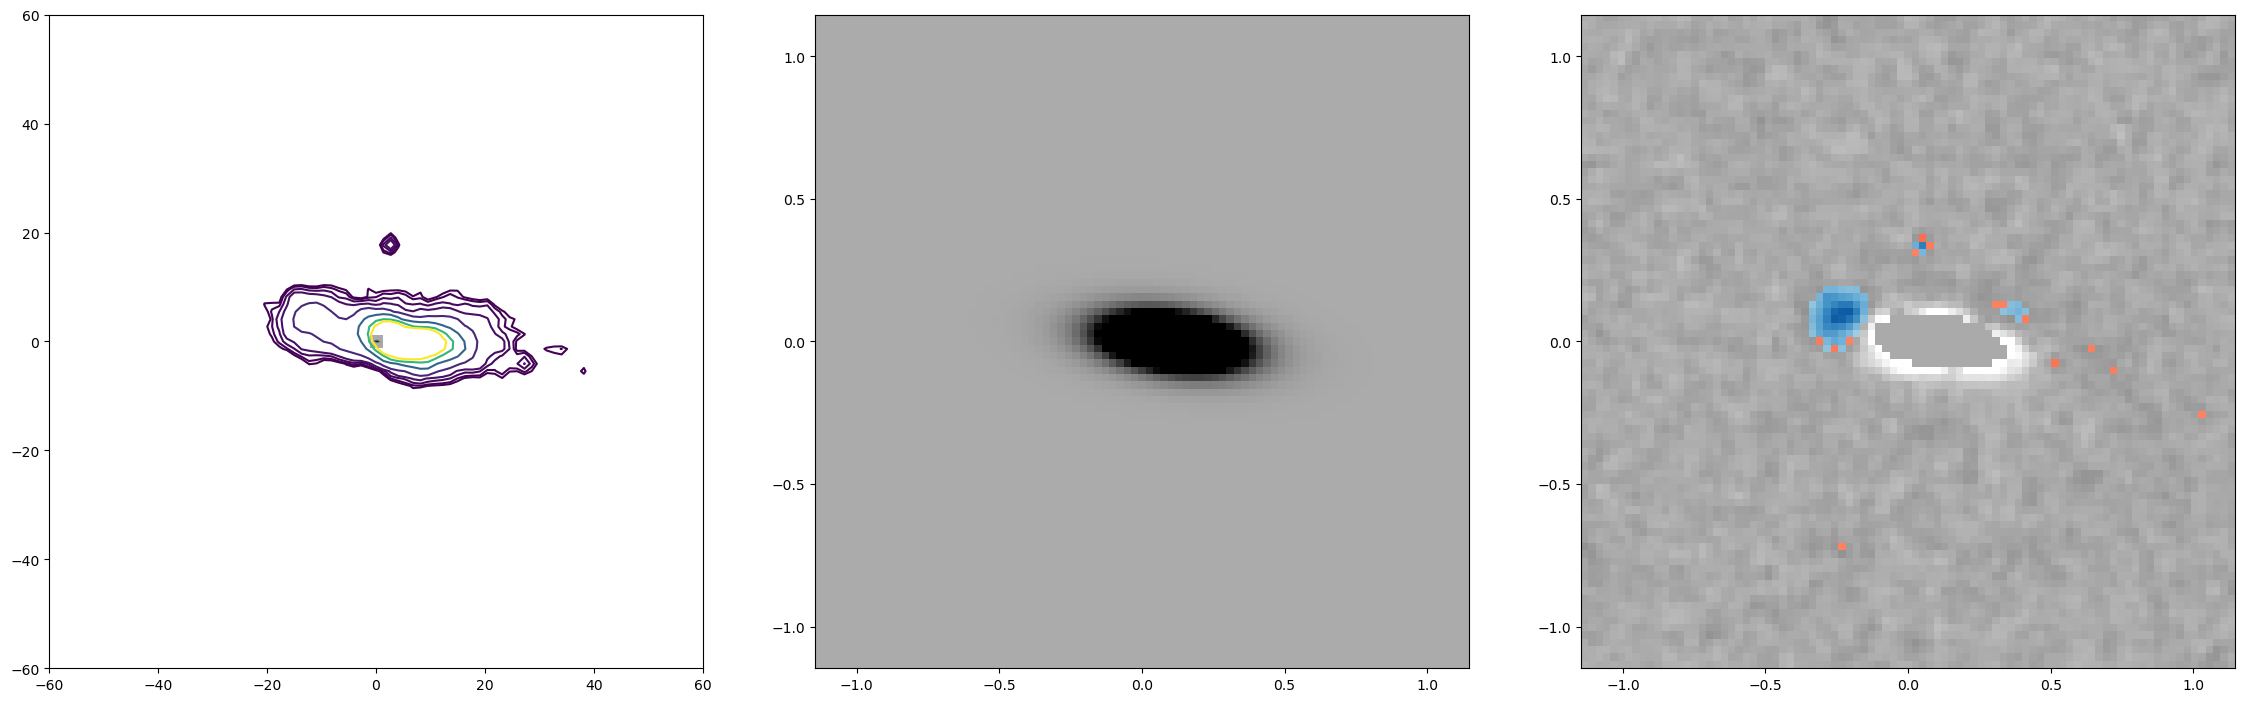

Filename: ../matched_filter/mf_data/mf_catalogs/26p5_2000/storm_2/mf_storm_2_d=90.0_a=77.3_pix=8000.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (89, 89)   float64   
z_fit_max: 41.76019217014648


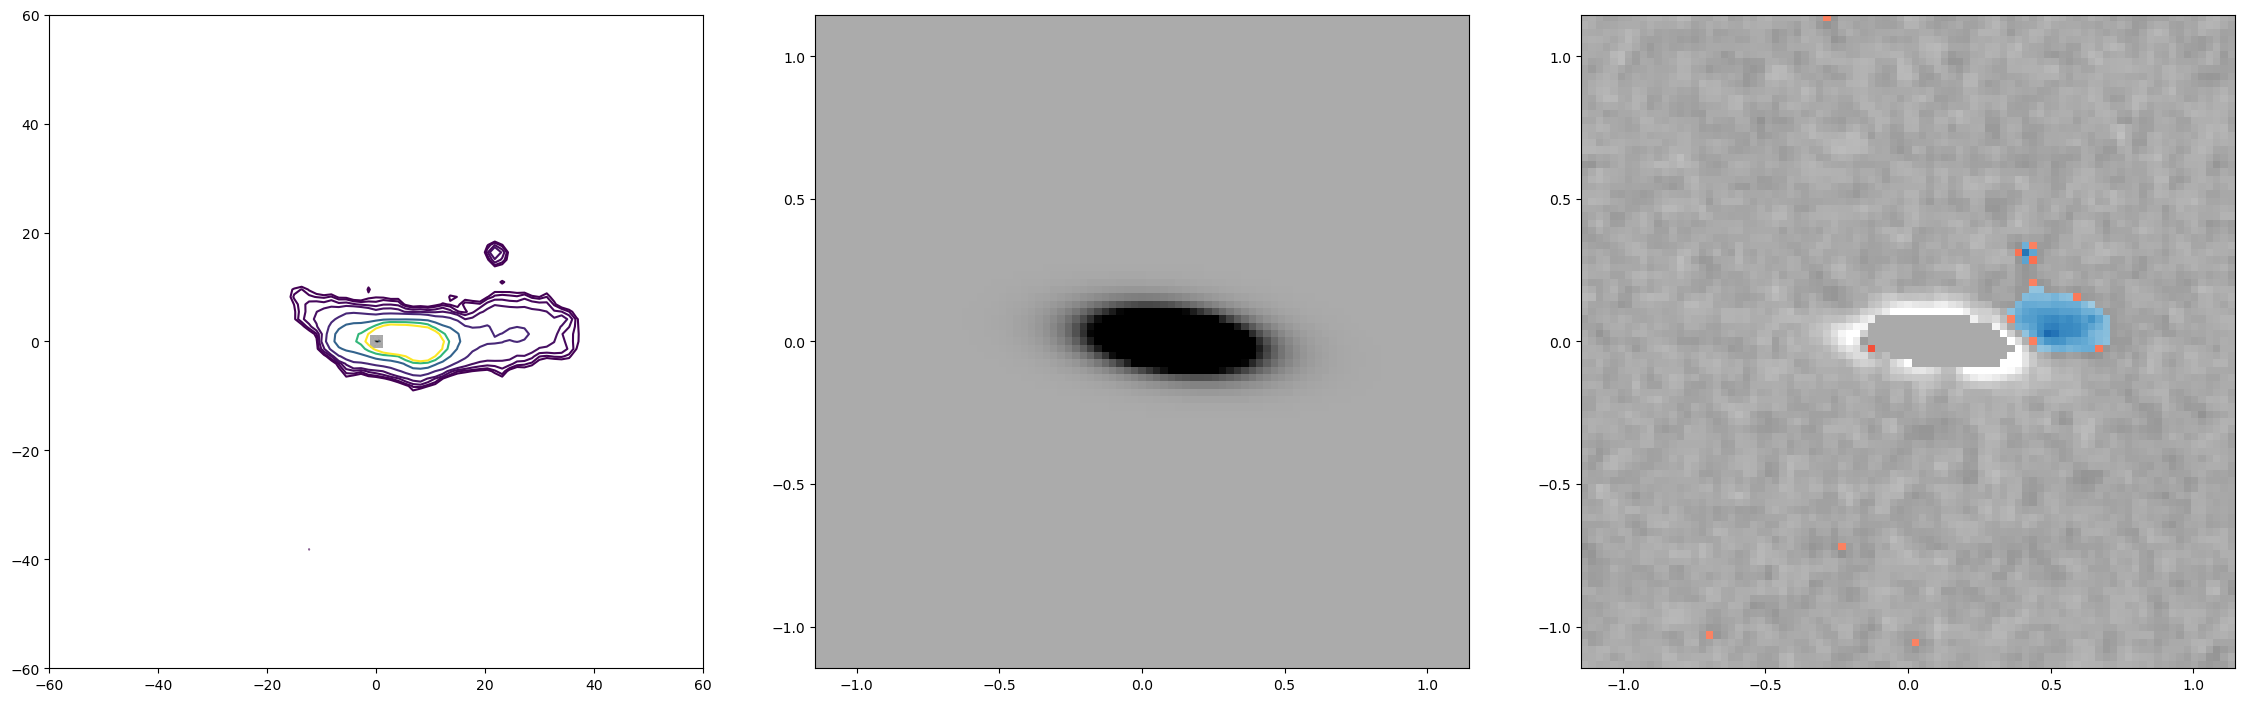

In [49]:
mf_exp_fit_edge_detect(fits_path, pdist, pix, initial_guess, mask_cutoff)